# Financial Time Series EDA: Feature Relationships for SPY (Daily)

**Goal**: explore the relationships among technical features derived from SPY's OHLCV data and the same-day returns of 9 related stocks/ETFs,
and examine how these features relate to SPY's next-day direction.
This notebook performs **data analysis and visualization only — no models are trained**.

**Data**: `data/yfinance_prices.csv` (yfinance export, long format, 10 tickers, 2018-01-02 to 2026-09-01, daily bars).

**Conventions (confirmed with the requester)**
- Primary target: **SPY**; same-day returns of the other 9 tickers (AAPL, AMZN, GOOGL, JPM, META, MSFT, NVDA, QQQ, XOM) are used as exogenous features.
- Returns and the up/down label use **`adj_close`** (split- and dividend-adjusted).
- The 2026-08-28 bar missing for JPM and XOM is **kept as missing** — no filling of any kind.

**No-leakage rule**: every feature at day t uses only data up to and including day t (all rolling windows look backward).
The labels `y` and `next_ret` are the only columns that use t+1 information; they are used only to observe feature–direction relationships and never enter feature construction.

| Section | Content |
|---|---|
| 0 | Environment and plotting setup |
| 1 | Data loading and overview |
| 2 | Data cleaning and feature engineering |
| 3 | Univariate analysis |
| 4 | Relationships between features (focus) |
| 5 | Features vs. next-day direction |
| 6 | Summary |

## 0. Environment and plotting setup

In [1]:
import logging
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
from matplotlib.patches import Patch
import seaborn as sns
from scipy import stats
from scipy.cluster import hierarchy
from scipy.spatial.distance import squareform
from statsmodels.tsa.stattools import adfuller, acf
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from sklearn.feature_selection import mutual_info_classif, mutual_info_regression

warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

DATA_PATH = Path("data/yfinance_prices.csv")
FIG_DIR = Path("figures")
FIG_DIR.mkdir(exist_ok=True)
TARGET = "SPY"
SEED = 42

# ---- Palette: fixed-order categorical hues, blue-gray-red diverging map ----
C = {
    "blue": "#2a78d6", "orange": "#eb6834", "aqua": "#1baf7a",
    "ink": "#0b0b0b", "ink2": "#52514e", "muted": "#898781",
    "grid": "#e1e0d9", "axis": "#c3c2b7", "surface": "#fcfcfb",
}
DIVERGING = LinearSegmentedColormap.from_list(
    "blue_gray_red", ["#104281", "#3987e5", "#f0efec", "#e66767", "#a8282a"])
UP_DOWN = {1: C["blue"], 0: C["orange"]}   # 1 = next day up, 0 = next day down/flat

mpl.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["DejaVu Sans", "Arial", "Helvetica"],
    "figure.facecolor": C["surface"], "axes.facecolor": C["surface"],
    "savefig.facecolor": C["surface"],
    "axes.edgecolor": C["axis"], "axes.labelcolor": C["ink2"],
    "axes.titlecolor": C["ink"], "axes.titlesize": 11, "axes.labelsize": 9,
    "xtick.color": C["muted"], "ytick.color": C["muted"],
    "xtick.labelsize": 8, "ytick.labelsize": 8,
    "axes.grid": True, "grid.color": C["grid"], "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.prop_cycle": mpl.cycler(color=[C["blue"], C["orange"], C["aqua"]]),
    "lines.linewidth": 1.4, "axes.axisbelow": True, "legend.frameon": False, "legend.fontsize": 8,
    "figure.dpi": 100, "savefig.dpi": 130,
})


def save(fig, name, title, caption):
    """Add a title and a bottom caption to the figure, then save it to figures/."""
    fig.suptitle(title, fontsize=14, color=C["ink"], x=0.01, ha="left", fontweight="bold")
    fig.text(0.01, 0.005, caption, fontsize=9, color=C["ink2"], ha="left", va="bottom", wrap=True)
    fig.tight_layout(rect=(0, 0.045, 1, 0.97))
    path = FIG_DIR / f"{name}.png"
    fig.savefig(path, bbox_inches="tight")
    plt.show()
    print(f"Saved: {path}")

## 1. Data loading and overview

In [2]:
raw = pd.read_csv(DATA_PATH, parse_dates=["date"])
print("shape:", raw.shape)
print("\ndtypes:\n", raw.dtypes)
print("\nMissing values:\n", raw.isna().sum())
print("\nDate range:", raw["date"].min().date(), "to", raw["date"].max().date())
raw.head()

shape: (21778, 8)

dtypes:
 date         datetime64[us]
ticker                  str
open                float64
high                float64
low                 float64
close               float64
adj_close           float64
volume                int64
dtype: object

Missing values:
 date         0
ticker       0
open         0
high         0
low          0
close        0
adj_close    0
volume       0
dtype: int64

Date range: 2018-01-02 to 2026-09-01


,date,ticker,open,high,low,close,adj_close,volume
0,2018-01-02,AAPL,42.540001,43.075001,42.314999,43.064999,40.232376,102223600
1,2018-01-03,AAPL,43.132500,43.637501,42.990002,43.057499,40.225365,118071600
2,2018-01-04,AAPL,43.134998,43.367500,43.020000,43.257500,40.412209,89738400
3,2018-01-05,AAPL,43.360001,43.842499,43.262501,43.750000,40.872330,94640000
4,2018-01-08,AAPL,43.587502,43.902500,43.482498,43.587502,40.720505,82271200


In [3]:
summary = raw.groupby("ticker").agg(
    rows=("date", "size"), start=("date", "min"), end=("date", "max"),
    dup_dates=("date", lambda s: s.duplicated().sum()),
    zero_volume=("volume", lambda s: (s == 0).sum()),
)
all_dates = pd.DatetimeIndex(sorted(raw["date"].unique()))
summary["missing_days"] = [len(all_dates.difference(raw.loc[raw.ticker == t, "date"])) for t in summary.index]
summary

,rows,start,end,dup_dates,zero_volume,missing_days
ticker,,,,,,
AAPL,2178,2018-01-02,2026-09-01,0,0,0
AMZN,2178,2018-01-02,2026-09-01,0,0,0
GOOGL,2178,2018-01-02,2026-09-01,0,0,0
JPM,2177,2018-01-02,2026-09-01,0,0,1
META,2178,2018-01-02,2026-09-01,0,0,0
MSFT,2178,2018-01-02,2026-09-01,0,0,0
NVDA,2178,2018-01-02,2026-09-01,0,0,0
QQQ,2178,2018-01-02,2026-09-01,0,0,0
SPY,2178,2018-01-02,2026-09-01,0,0,0


In [4]:
raw.groupby("ticker")[["adj_close", "volume"]].describe().round(1)

adj_close                                                   volume                                                                               \
           count   mean    std    min    25%    50%    75%    max   count         mean          std         min          25%          50%          75%   
ticker                                                                                                                                                   
AAPL      2178.0  146.6   75.7   33.7   70.3  146.8  196.8  339.8  2178.0   91031588.9   54025576.4  17910600.0   52391125.0   76705400.0  111897225.0   
AMZN      2178.0  148.0   52.8   59.5   95.6  150.9  183.1  284.0  2178.0   70350006.5   38865872.8  11420500.0   43999975.0   59977000.0   85354500.0   
GOOGL     2178.0  131.7   80.0   48.8   67.0  115.7  160.1  402.4  2178.0   33905260.4   15230860.2   9312000.0   24273000.0   30173750.0   38565850.0   
JPM       2177.0  154.7   75.9   66.5   93.5  129.5  192.9  365.2  2177.0   12492655.3    6314175.2   3220500.0    8402700.0   10772000.0   14342200.0   
META      2178.0  337.1  187.5   88.1  183.7  270.5  499.4  787.4  2178.0   21497939.6   14887851.9   4726100.0   13104775.0   17786150.0   24818075.0   
MSFT      2178.0  274.5  127.7   77.7  156.4  266.6  394.5  537.6  2178.0   28372138.5   12968832.8   5855900.0   20132800.0   25286650.0   32747075.0   
NVDA      2178.0   56.2   66.3    3.1    6.7   19.8  107.7  235.5  2178.0  411569676.9  219837897.2  65528500.0  244441000.0  380789000.0  524125000.0   
QQQ       2178.0  347.7  153.9  137.0  207.4  320.7  451.8  745.3  2178.0   47020902.4   21828919.7   7089000.0   31627950.0   42810300.0   57148025.0   
SPY       2178.0  416.8  147.3  204.4  281.8  393.1  520.9  777.9  2178.0   79762346.8   39734714.7  20270000.0   55526575.0   71174200.0   92242325.0   
XOM       2177.0   78.3   33.2   23.7   51.5   73.7  103.8  169.2  2177.0   19143581.9    9433747.0   3979400.0   13145300.0   16627700.0   22415300.0   

                      
                 max  
ticker                
AAPL    4.265100e+08  
AMZN    3.113460e+08  
GOOGL   1.331780e+08  
JPM     5.441880e+07  
META    2.323166e+08  
MSFT    1.862016e+08  
NVDA    2.511528e+09  
QQQ     1.986858e+08  
SPY     3.922207e+08  
XOM     8.443940e+07

## 2. Data cleaning and feature engineering

### 2.1 Cleaning checks
Sort by date; check for duplicate dates, missing days, OHLC consistency, non-positive prices, zero volume and extreme returns.

In [5]:
df = raw.sort_values(["ticker", "date"]).reset_index(drop=True)

checks = {
    "duplicate (ticker, date)": df.duplicated(["ticker", "date"]).sum(),
    "high < max(open, close, low)": (df["high"] < df[["open", "close", "low"]].max(axis=1)).sum(),
    "low > min(open, close, high)": (df["low"] > df[["open", "close", "high"]].min(axis=1)).sum(),
    "non-positive price": (df[["open", "high", "low", "close", "adj_close"]] <= 0).sum().sum(),
    "zero volume": (df["volume"] == 0).sum(),
}
print(pd.Series(checks, name="count"))

for t in ["JPM", "XOM"]:
    miss = all_dates.difference(df.loc[df.ticker == t, "date"])
    print(f"{t} missing dates:", [d.date() for d in miss])

# Split check: if close is already split-adjusted, close and adj_close returns differ only by dividends
tmp = df.assign(r_adj=df.groupby("ticker")["adj_close"].pct_change(fill_method=None),
                r_close=df.groupby("ticker")["close"].pct_change(fill_method=None))
print("Rows where close vs adj_close daily return differs by > 5%:", ((tmp.r_adj - tmp.r_close).abs() > 0.05).sum())

extreme = tmp.loc[tmp["r_adj"].abs() > 0.15, ["date", "ticker", "r_adj"]]
print(f"\nObservations with |daily return| > 15% ({len(extreme)} in total):")
extreme

duplicate (ticker, date)        0
high < max(open, close, low)    0
low > min(open, close, high)    0
non-positive price              0
zero volume                     0
Name: count, dtype: int64
JPM missing dates: [datetime.date(2026, 8, 28)]
XOM missing dates: [datetime.date(2026, 8, 28)]
Rows where close vs adj_close daily return differs by > 5%: 0

Observations with |daily return| > 15% (17 in total):


,date,ticker,r_adj
1827,2025-04-09,AAPL,0.153288
4333,2026-07-31,AMZN,0.153206
7086,2020-03-13,JPM,0.180125
8853,2018-07-26,META,-0.189609
9741,2022-02-03,META,-0.263901
9799,2022-04-28,META,0.175936
9925,2022-10-27,META,-0.245571
9991,2023-02-02,META,0.232824
10242,2024-02-02,META,0.203176
13043,2026-07-30,MSFT,0.155067


**Cleaning conclusions and handling**
- No duplicate dates, no OHLC inconsistencies, no non-positive prices, no zero volume.
- Only JPM and XOM miss one day (2026-08-28): **kept as NaN** — no forward fill and no interpolation from later data.
  Because returns are computed on the aligned wide table with `pct_change(fill_method=None)` / `log(P / P.shift(1))`, both that day and the following day get NaN returns, so no spurious two-day return is created.
- `close` is already split-adjusted (no jumps on split dates); `adj_close` additionally adjusts for dividends, so all returns use `adj_close`.
- Extreme returns (|r| > 15%) all correspond to real market events (March 2020 COVID crash, earnings days, the 2025-01-27 DeepSeek shock, the 2025-04-09 tariff pause) and are **kept**.
  Financial returns are naturally fat-tailed and removing them would understate risk; to limit their influence on linear correlation, Spearman (rank) correlation is reported alongside Pearson throughout.

### 2.2 Feature engineering (information up to t only)

| Feature | Definition |
|---|---|
| `ret_1d` | Daily log return ln(P_t / P_{t-1}) |
| `ret_5d`, `ret_20d` | Cumulative log return over the past 5 / 20 days |
| `ret_lag1` … `ret_lag5` | Returns lagged 1–5 periods (`ret_1d` shifted backward) |
| `vol_20d`, `vol_60d` | Std. dev. of returns over the past 20 / 60 days × √252 (annualized) |
| `ma_dev_20/50/200` | P_t / SMA_n(P) - 1, deviation from moving average |
| `rsi_14` | 14-day RSI with Wilder smoothing |
| `macd`, `macd_signal`, `macd_hist` | (EMA12 - EMA26), its 9-day EMA, and their difference — **all divided by P_t** so they do not drift with the price level |
| `vol_chg` | Log change in volume ln(V_t / V_{t-1}) |
| `vol_ratio_20` | V_t / average volume over the past 20 days |
| `hl_range` | (High_t - Low_t) / Close_t, intraday range |
| `gap` | Open_t / Close_{t-1} - 1, overnight gap |
| `r_AAPL` … `r_XOM` | **Same-day** log returns of the other 9 tickers (known at the close of day t) |

**Labels** (for observation only): `next_ret` = ln(P_{t+1}/P_t), `y` = 1 if adj_close(t+1) > adj_close(t) else 0.

In [6]:
# Wide table aligned on SPY's trading calendar (JPM/XOM missing day stays NaN)
wide_adj = df.pivot(index="date", columns="ticker", values="adj_close").sort_index()
log_ret = np.log(wide_adj / wide_adj.shift(1))   # NaN on and after a missing day; never spans two days

s = df[df.ticker == TARGET].set_index("date").sort_index()
P, V = s["adj_close"], s["volume"]


def rsi_wilder(price, n=14):
    delta = price.diff()
    gain = delta.clip(lower=0).ewm(alpha=1 / n, adjust=False, min_periods=n).mean()
    loss = (-delta.clip(upper=0)).ewm(alpha=1 / n, adjust=False, min_periods=n).mean()
    return 100 - 100 / (1 + gain / loss)


feat = pd.DataFrame(index=s.index)
feat["ret_1d"] = np.log(P / P.shift(1))
feat["ret_5d"] = feat["ret_1d"].rolling(5).sum()
feat["ret_20d"] = feat["ret_1d"].rolling(20).sum()
for k in range(1, 6):
    feat[f"ret_lag{k}"] = feat["ret_1d"].shift(k)
feat["vol_20d"] = feat["ret_1d"].rolling(20).std() * np.sqrt(252)
feat["vol_60d"] = feat["ret_1d"].rolling(60).std() * np.sqrt(252)
for n in (20, 50, 200):
    feat[f"ma_dev_{n}"] = P / P.rolling(n).mean() - 1
feat["rsi_14"] = rsi_wilder(P, 14)
ema12, ema26 = P.ewm(span=12, adjust=False).mean(), P.ewm(span=26, adjust=False).mean()
macd_line = ema12 - ema26
macd_sig = macd_line.ewm(span=9, adjust=False).mean()
feat["macd"] = macd_line / P
feat["macd_signal"] = macd_sig / P
feat["macd_hist"] = (macd_line - macd_sig) / P
feat["vol_chg"] = np.log(V / V.shift(1))
feat["vol_ratio_20"] = V / V.rolling(20).mean()
feat["hl_range"] = (s["high"] - s["low"]) / s["close"]
feat["gap"] = s["open"] / s["close"].shift(1) - 1
OTHERS = [t for t in wide_adj.columns if t != TARGET]
for t in OTHERS:
    feat[f"r_{t}"] = log_ret[t]

# ---- Labels: the only columns that use t+1 information ----
labels = pd.DataFrame(index=s.index)
labels["next_ret"] = np.log(P.shift(-1) / P)
labels["y"] = (P.shift(-1) > P).astype(float).where(P.shift(-1).notna())

FEATURES = list(feat.columns)
print(f"Number of features: {len(FEATURES)}")
print(FEATURES)

Number of features: 30
['ret_1d', 'ret_5d', 'ret_20d', 'ret_lag1', 'ret_lag2', 'ret_lag3', 'ret_lag4', 'ret_lag5', 'vol_20d', 'vol_60d', 'ma_dev_20', 'ma_dev_50', 'ma_dev_200', 'rsi_14', 'macd', 'macd_signal', 'macd_hist', 'vol_chg', 'vol_ratio_20', 'hl_range', 'gap', 'r_AAPL', 'r_AMZN', 'r_GOOGL', 'r_JPM', 'r_META', 'r_MSFT', 'r_NVDA', 'r_QQQ', 'r_XOM']


In [7]:
# ---- Leakage self-check: recompute after truncating future data; values at t must not change ----
def build_spy_features(cut):
    """Recompute a subset of features seeing only data up to `cut`."""
    Pc = P.loc[:cut]
    out = pd.DataFrame(index=Pc.index)
    out["ret_20d"] = np.log(Pc / Pc.shift(1)).rolling(20).sum()
    out["ma_dev_200"] = Pc / Pc.rolling(200).mean() - 1
    out["rsi_14"] = rsi_wilder(Pc, 14)
    m = Pc.ewm(span=12, adjust=False).mean() - Pc.ewm(span=26, adjust=False).mean()
    out["macd_hist"] = (m - m.ewm(span=9, adjust=False).mean()) / Pc
    return out

for cut in ["2020-03-16", "2023-06-30", "2026-01-02"]:
    part = build_spy_features(cut)
    diff = (part - feat.loc[:cut, part.columns]).abs().max().max()
    print(f"Truncated at {cut}: max abs difference vs. full-sample features = {diff:.2e}")

Truncated at 2020-03-16: max abs difference vs. full-sample features = 0.00e+00
Truncated at 2023-06-30: max abs difference vs. full-sample features = 0.00e+00
Truncated at 2026-01-02: max abs difference vs. full-sample features = 0.00e+00


In [8]:
data = feat.join(labels)
n_before = len(data)
data = data.dropna(subset=FEATURES + ["y"])   # drop the 200-day warm-up, the last day (no label) and the JPM/XOM missing days
print(f"Samples: {n_before} -> {len(data)} ({data.index.min().date()} to {data.index.max().date()})")
print("Share of next-day up moves (y=1):", round(data["y"].mean(), 4))
data[FEATURES].describe().T.round(4)

Samples: 2178 -> 1976 (2018-10-16 to 2026-08-27)
Share of next-day up moves (y=1): 0.5526


,count,mean,std,min,25%,50%,75%,max
ret_1d,1976.0,0.0006,0.0123,-0.1159,-0.0044,0.0009,0.0066,0.0999
ret_5d,1976.0,0.0029,0.0252,-0.1981,-0.0086,0.0053,0.0163,0.1601
ret_20d,1976.0,0.0111,0.0500,-0.3709,-0.0101,0.0196,0.0400,0.2076
ret_lag1,1976.0,0.0006,0.0123,-0.1159,-0.0044,0.0009,0.0066,0.0999
ret_lag2,1976.0,0.0006,0.0123,-0.1159,-0.0044,0.0009,0.0066,0.0999
ret_lag3,1976.0,0.0006,0.0123,-0.1159,-0.0044,0.0009,0.0066,0.0999
ret_lag4,1976.0,0.0006,0.0123,-0.1159,-0.0044,0.0009,0.0066,0.0999
ret_lag5,1976.0,0.0006,0.0123,-0.1159,-0.0044,0.0009,0.0066,0.0999
vol_20d,1976.0,0.1645,0.1074,0.0475,0.1046,0.1376,0.1921,0.9392
vol_60d,1976.0,0.1717,0.0943,0.0669,0.1153,0.1425,0.1970,0.6179


## 3. Univariate analysis

### 3.1 Feature distributions (histogram + KDE, with skewness / excess kurtosis)

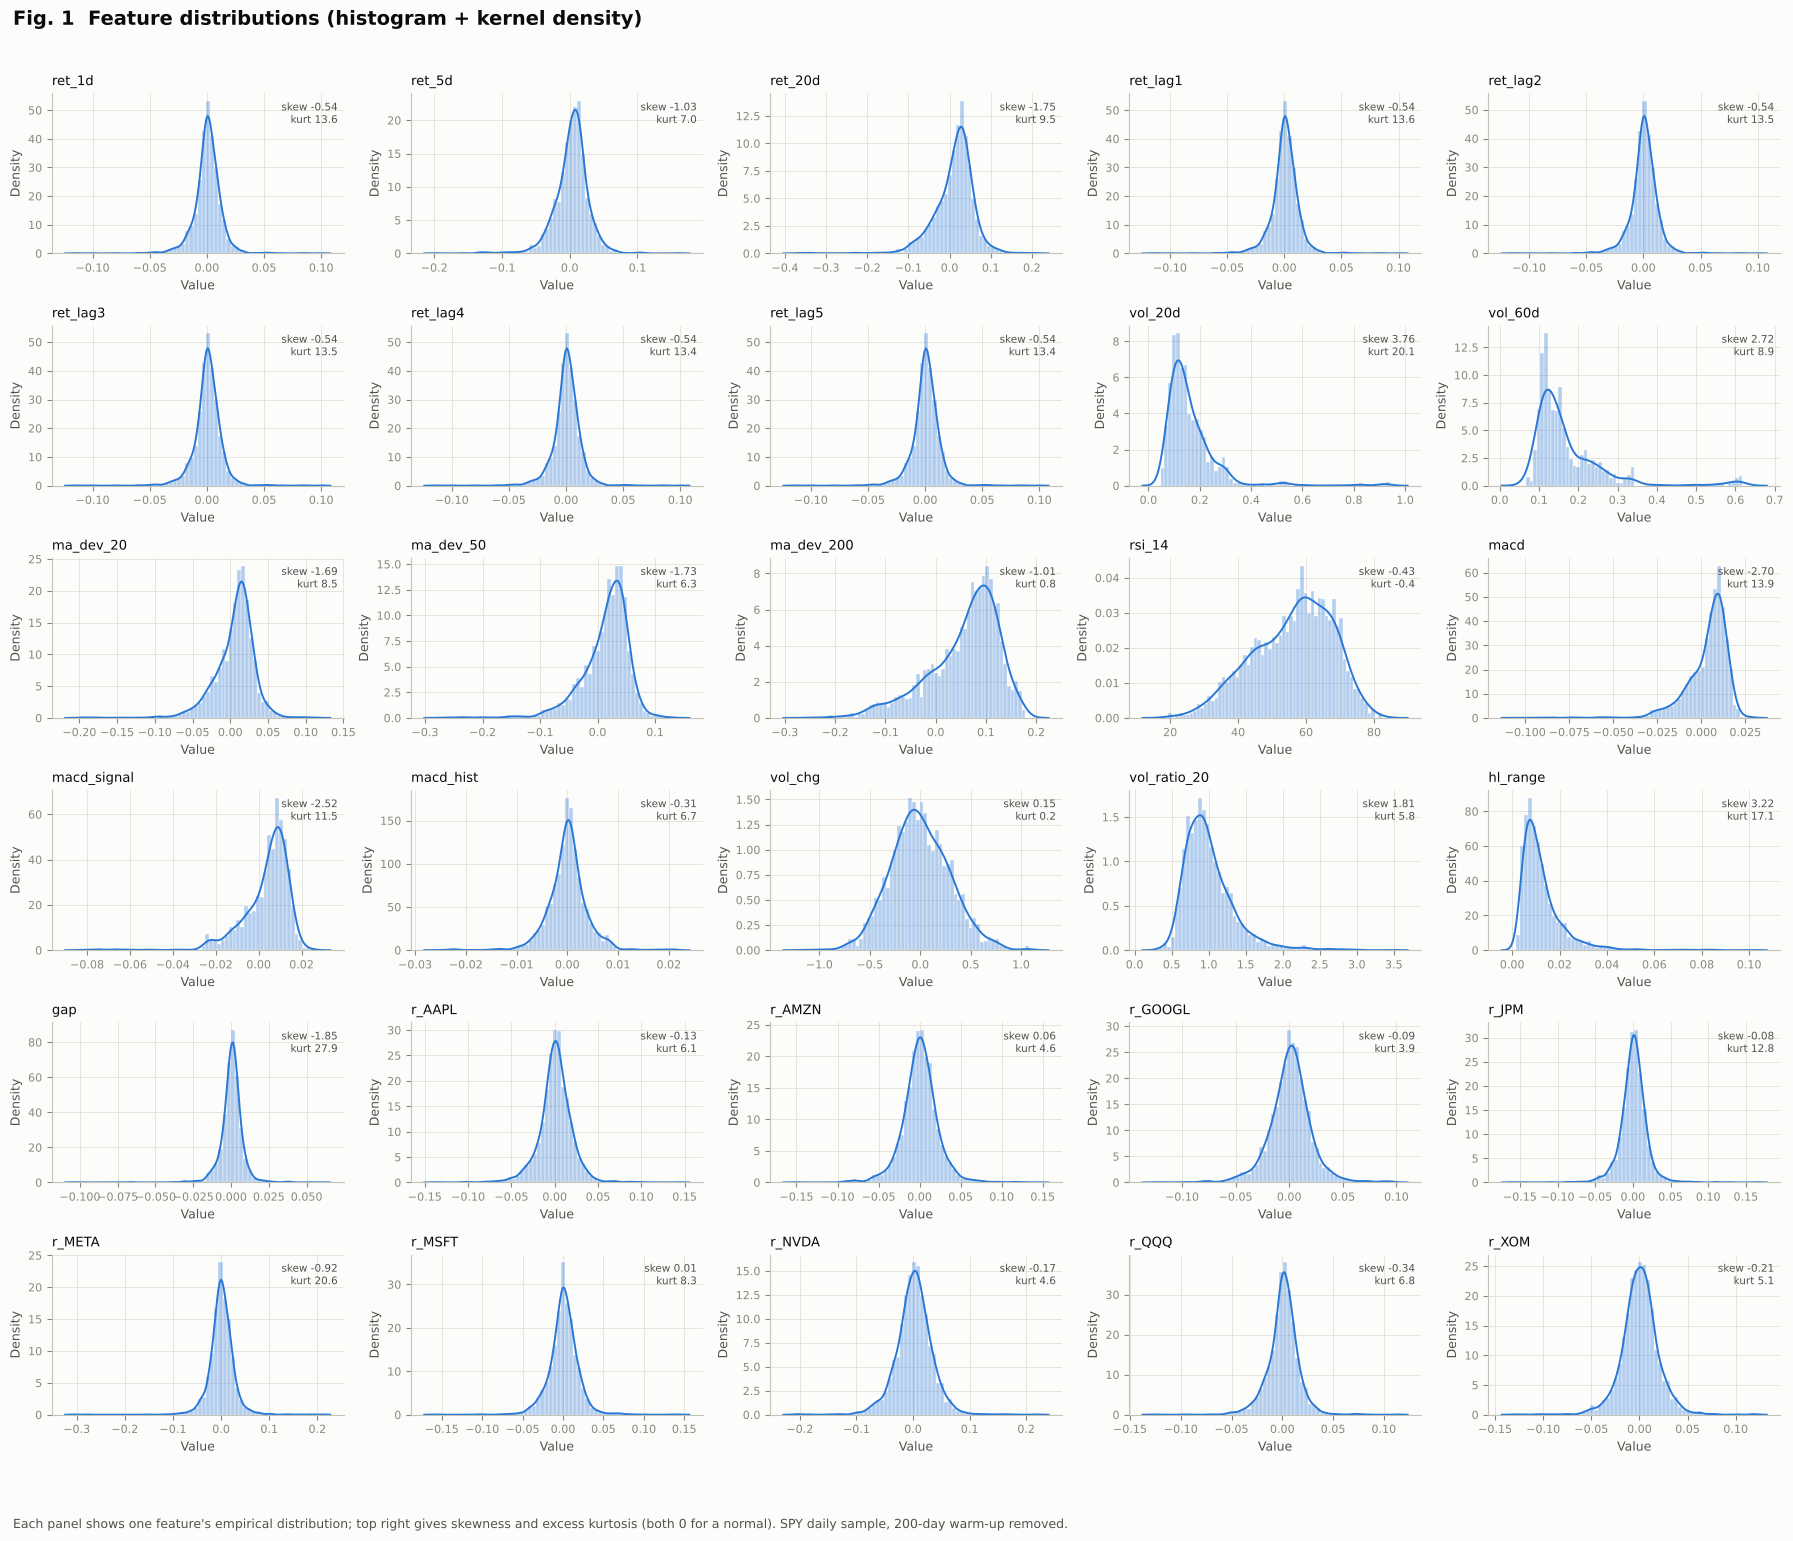

Saved: figures/01_feature_distributions.png


,skew,excess_kurtosis
feature,,
gap,-1.85,27.87
r_META,-0.92,20.55
vol_20d,3.76,20.11
hl_range,3.22,17.11
macd,-2.70,13.87
ret_1d,-0.54,13.57
ret_lag1,-0.54,13.57
ret_lag2,-0.54,13.55
ret_lag3,-0.54,13.49


In [9]:
ncol = 5
nrow = int(np.ceil(len(FEATURES) / ncol))
fig, axes = plt.subplots(nrow, ncol, figsize=(18, 2.6 * nrow))
moments = []
for ax, f in zip(axes.flat, FEATURES):
    x = data[f]
    sk, ku = stats.skew(x), stats.kurtosis(x)   # excess kurtosis (normal = 0)
    moments.append((f, sk, ku))
    sns.histplot(x, bins=60, stat="density", ax=ax, color=C["blue"], alpha=0.35, edgecolor=C["surface"], linewidth=0.3)
    sns.kdeplot(x, ax=ax, color=C["blue"], linewidth=1.4)
    ax.set_title(f, fontsize=9.5, loc="left")
    ax.text(0.98, 0.95, f"skew {sk:.2f}\nkurt {ku:.1f}", transform=ax.transAxes, ha="right", va="top",
            fontsize=7.5, color=C["ink2"])
    ax.set_xlabel("Value"); ax.set_ylabel("Density")
for ax in axes.flat[len(FEATURES):]:
    ax.axis("off")
save(fig, "01_feature_distributions", "Fig. 1  Feature distributions (histogram + kernel density)",
     "Each panel shows one feature's empirical distribution; top right gives skewness and excess kurtosis (both 0 for a normal). SPY daily sample, 200-day warm-up removed.")
moments = pd.DataFrame(moments, columns=["feature", "skew", "excess_kurtosis"]).set_index("feature").round(2)
moments.sort_values("excess_kurtosis", ascending=False).head(10)

**Observation:** Almost every feature departs clearly from normality. All return series (including the 9 exogenous stocks) are leptokurtic and fat-tailed: SPY's daily return has excess kurtosis of about 13.6 and is left-skewed (-0.54), so large drops are more extreme than large rallies; the overnight `gap` has the highest kurtosis (~28). Volatility-type features (`vol_20d`, `vol_60d`, `hl_range`, `vol_ratio_20`) are strongly right-skewed, while MA deviations, MACD and RSI are left-skewed because the sample is mostly an uptrend. Before modeling, consider log-transforming the right-skewed features or using rank/quantile transforms.

### 3.2 QQ plots of returns (fat-tail check)

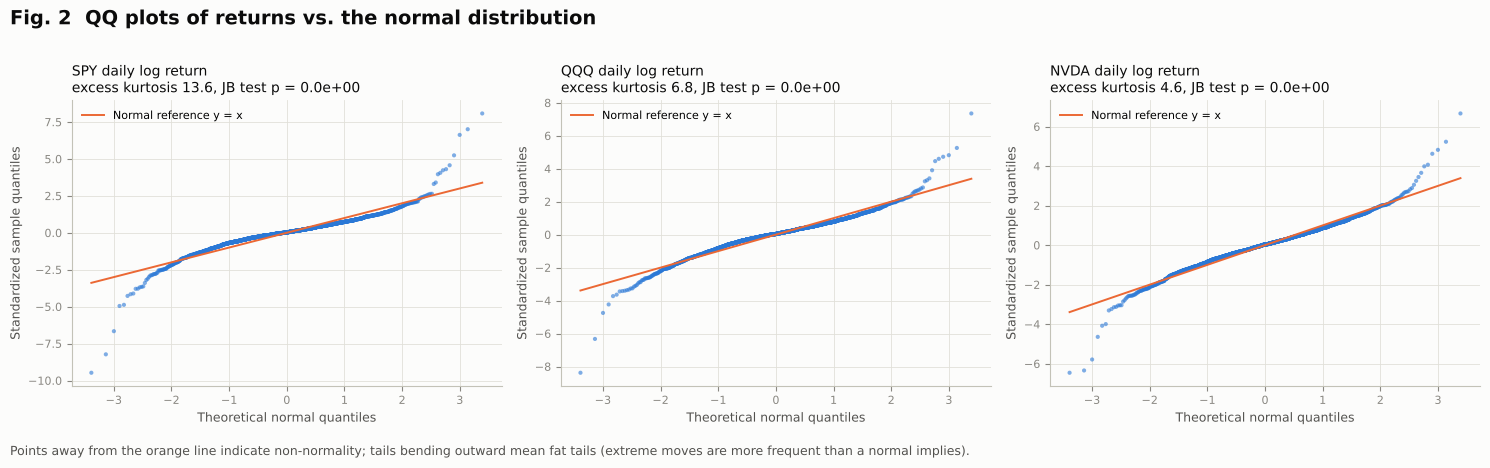

Saved: figures/02_returns_qq.png


In [10]:
qq_series = {"SPY daily log return": data["ret_1d"], "QQQ daily log return": data["r_QQQ"], "NVDA daily log return": data["r_NVDA"]}
fig, axes = plt.subplots(1, 3, figsize=(15, 4.6))
for ax, (name, x) in zip(axes, qq_series.items()):
    z = (x - x.mean()) / x.std()
    (osm, osr), (slope, intercept, r) = stats.probplot(z, dist="norm")
    ax.scatter(osm, osr, s=9, color=C["blue"], alpha=0.6, edgecolor="none")
    lim = [osm.min(), osm.max()]
    ax.plot(lim, lim, color=C["orange"], linewidth=1.4, label="Normal reference y = x")
    jb = stats.jarque_bera(x)
    ax.set_title(f"{name}\nexcess kurtosis {stats.kurtosis(x):.1f}, JB test p = {jb.pvalue:.1e}", loc="left", fontsize=10)
    ax.set_xlabel("Theoretical normal quantiles"); ax.set_ylabel("Standardized sample quantiles")
    ax.legend(loc="upper left")
save(fig, "02_returns_qq", "Fig. 2  QQ plots of returns vs. the normal distribution",
     "Points away from the orange line indicate non-normality; tails bending outward mean fat tails (extreme moves are more frequent than a normal implies).")

**Observation:** All three return series bend away from the reference line at both ends, and the Jarque-Bera p-values are essentially 0, so normality is strongly rejected. SPY shows the most pronounced tail deviation (highest excess kurtosis); NVDA is the most volatile, but its tails are relatively lighter once scaled by its own standard deviation. Risk estimates under a normal assumption would understate the frequency of extreme moves.

### 3.3 Price and volume over time

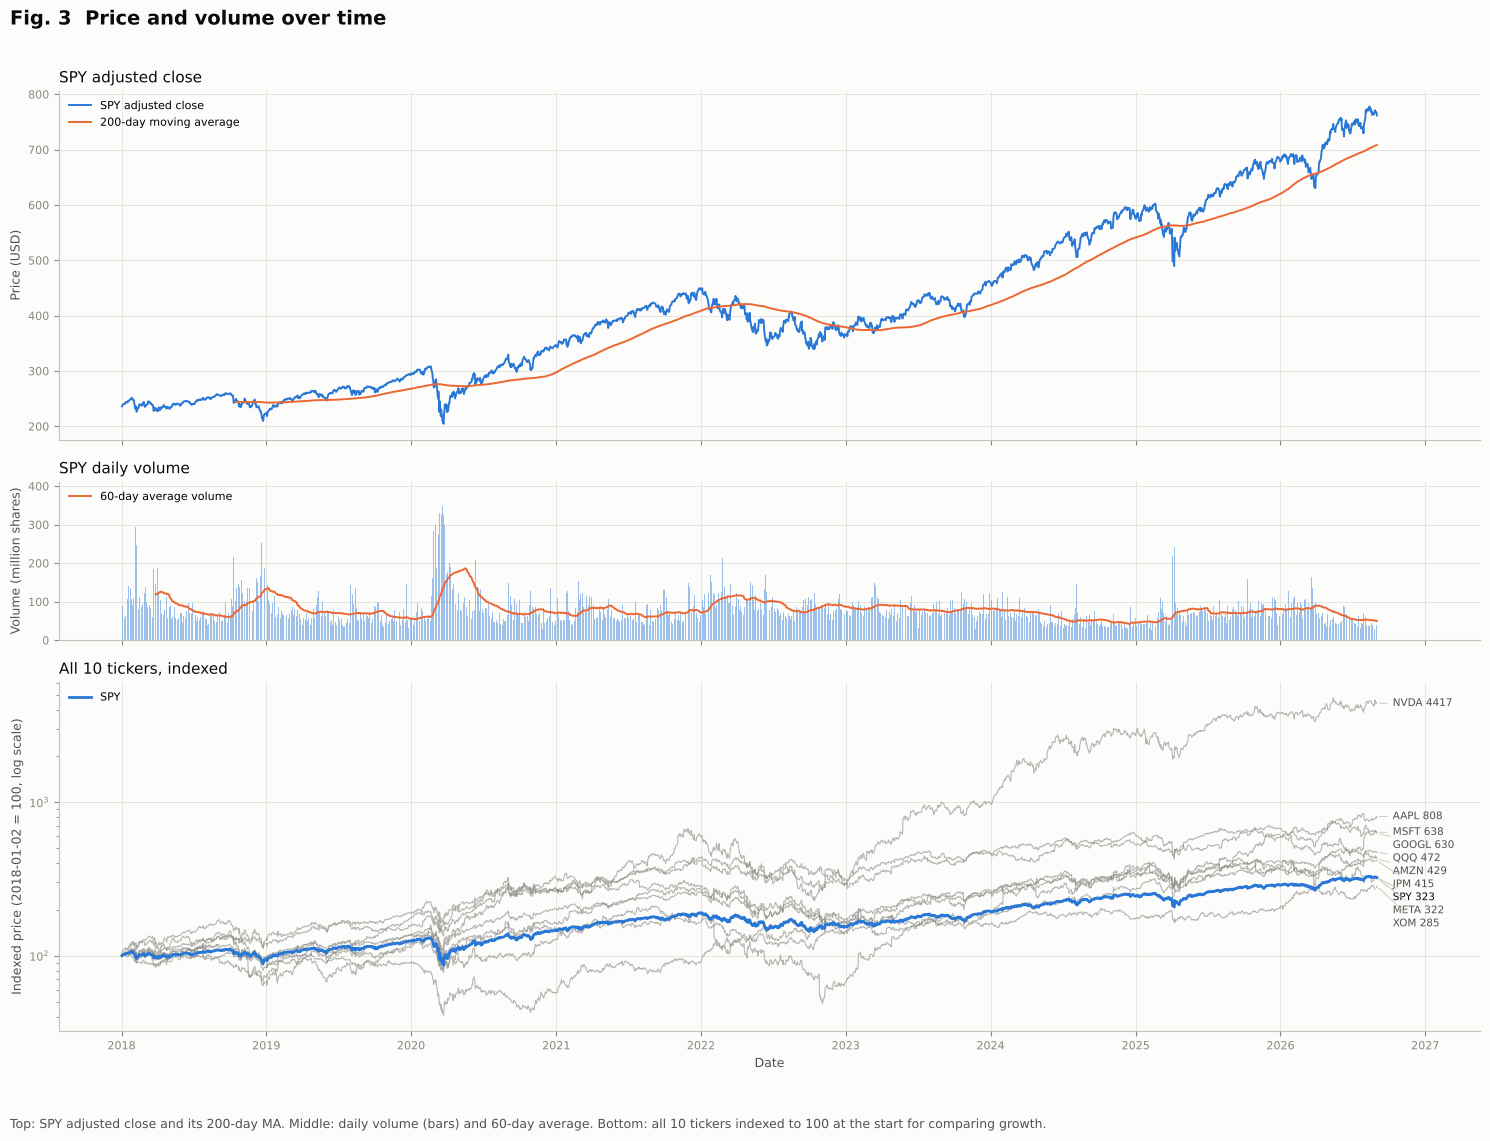

Saved: figures/03_price_volume_timeseries.png


In [11]:
fig, axes = plt.subplots(3, 1, figsize=(15, 11.5), sharex=True, gridspec_kw={"height_ratios": [2.2, 1, 2.2]})
ax = axes[0]
ax.plot(s.index, s["adj_close"], color=C["blue"], linewidth=1.4, label="SPY adjusted close")
ax.plot(s.index, s["adj_close"].rolling(200).mean(), color=C["orange"], linewidth=1.4, label="200-day moving average")
ax.set_ylabel("Price (USD)"); ax.set_title("SPY adjusted close", loc="left"); ax.legend(loc="upper left")
ax = axes[1]
ax.bar(s.index, s["volume"] / 1e6, width=1.0, color=C["blue"], alpha=0.45)
ax.plot(s.index, s["volume"].rolling(60).mean() / 1e6, color=C["orange"], linewidth=1.4, label="60-day average volume")
ax.set_ylabel("Volume (million shares)"); ax.set_title("SPY daily volume", loc="left"); ax.legend(loc="upper left")
ax = axes[2]
idx = wide_adj / wide_adj.bfill().iloc[0] * 100   # start-date normalization for plotting only (not a feature)
for t in idx.columns:
    ax.plot(idx.index, idx[t], color=C["muted"], linewidth=0.8, alpha=0.6)
# De-overlap end labels: push down in log space with a minimum gap
ends = sorted(((np.log10(idx[t].dropna().iloc[-1]), t) for t in idx.columns), reverse=True)
placed, min_gap = [], 0.085
for v, t in ends:
    y = min(v, placed[-1] - min_gap) if placed else v
    placed.append(y)
    ax.annotate(f"{t} {10 ** v:.0f}", xy=(idx.index[-1], 10 ** v), xytext=(idx.index[-1] + pd.Timedelta(days=40), 10 ** y),
                fontsize=7.5, color=C["ink"] if t == TARGET else C["ink2"], va="center",
                arrowprops={"arrowstyle": "-", "color": C["axis"], "linewidth": 0.6})
ax.set_xlim(right=idx.index[-1] + pd.Timedelta(days=260))
ax.plot(idx.index, idx[TARGET], color=C["blue"], linewidth=2, label="SPY")
ax.set_yscale("log"); ax.set_ylabel("Indexed price (2018-01-02 = 100, log scale)")
ax.set_title("All 10 tickers, indexed", loc="left"); ax.set_xlabel("Date"); ax.legend(loc="upper left")
save(fig, "03_price_volume_timeseries", "Fig. 3  Price and volume over time",
     "Top: SPY adjusted close and its 200-day MA. Middle: daily volume (bars) and 60-day average. Bottom: all 10 tickers indexed to 100 at the start for comparing growth.")

**Observation:** SPY's adjusted price rose about 3.2x over 2018–2026, with clear drawdowns in late 2018, March 2020, the 2022 bear market and April 2025, so the price level is clearly trending. Volume concentrates in sell-offs and high-volatility periods (especially March 2020) and is lower during calm rallies, hinting at a volume–volatility link. Dispersion across names is large: NVDA is up ~44x, XOM less than 3x.

### 3.4 ADF stationarity test

In [12]:
adf_input = data[FEATURES].copy()
adf_input["price_level(adj_close)"] = P.reindex(data.index)
adf_input["volume_level"] = V.reindex(data.index)
adf_input["log_price"] = np.log(P.reindex(data.index))

rows = []
for c in adf_input.columns:
    stat, p, lags, nobs, crit, _ = adfuller(adf_input[c].dropna(), autolag="AIC")
    rows.append({"series": c, "ADF stat": stat, "p-value": p, "lags": lags, "5% critical": crit["5%"]})
adf_tbl = pd.DataFrame(rows).set_index("series")
adf_tbl["stationary at 5%"] = np.where(adf_tbl["p-value"] < 0.05, "yes", "no")
adf_tbl = adf_tbl.sort_values("p-value", ascending=False)
print("Non-stationary series (p >= 0.05):", adf_tbl.index[adf_tbl["stationary at 5%"] == "no"].tolist())
adf_tbl.round(4)

Non-stationary series (p >= 0.05): ['price_level(adj_close)', 'log_price']


,ADF stat,p-value,lags,5% critical,stationary at 5%
series,,,,,
price_level(adj_close),0.6941,0.9897,9,-2.863,no
log_price,-0.5695,0.8777,9,-2.863,no
ma_dev_200,-3.7994,0.0029,9,-2.863,yes
vol_60d,-4.1298,0.0009,8,-2.863,yes
vol_20d,-4.5632,0.0002,23,-2.863,yes
hl_range,-5.5355,0.0000,24,-2.863,yes
volume_level,-6.5165,0.0000,8,-2.863,yes
macd_signal,-6.6784,0.0000,20,-2.863,yes
ma_dev_50,-6.9290,0.0000,9,-2.863,yes


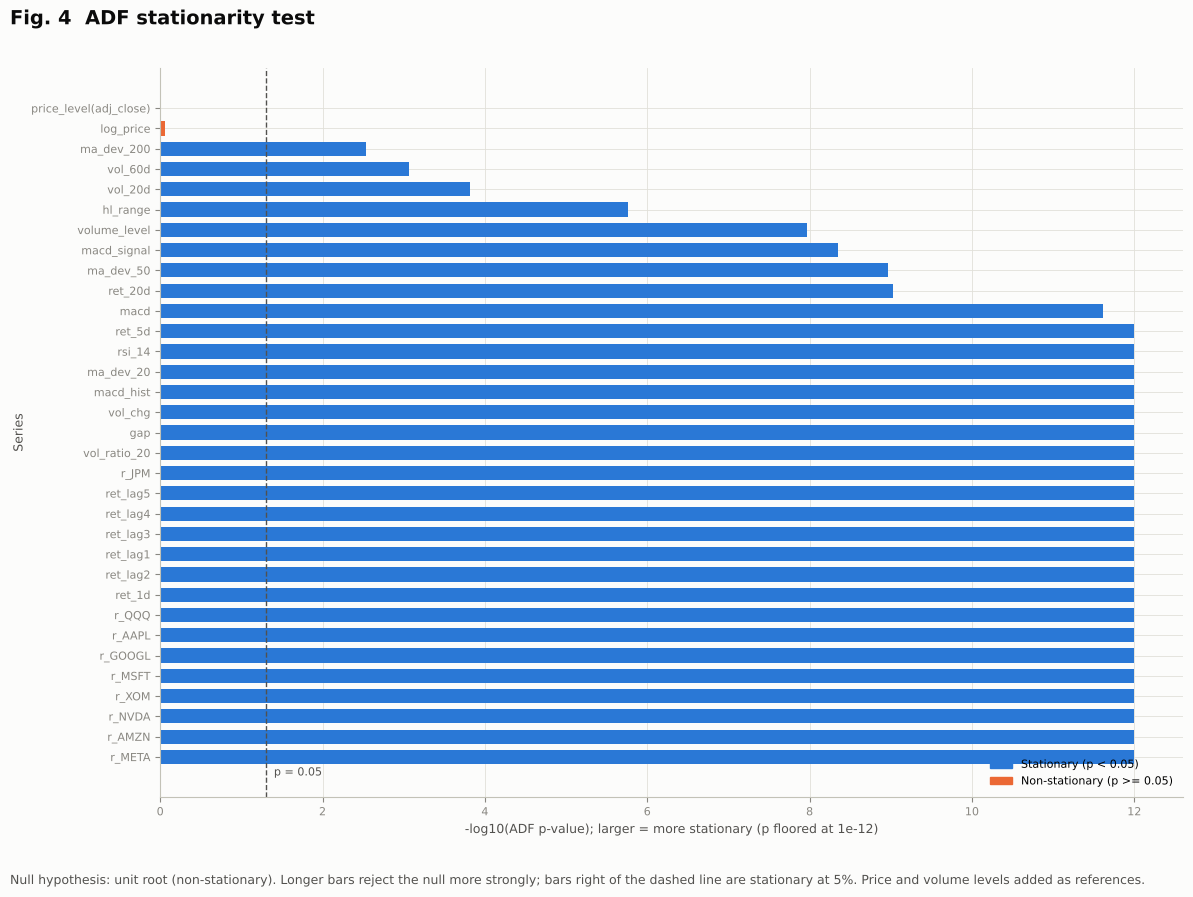

Saved: figures/04_adf_stationarity.png


In [13]:
fig, ax = plt.subplots(figsize=(12, 9))
plot_p = adf_tbl["p-value"].clip(lower=1e-12)
colors = [C["orange"] if p >= 0.05 else C["blue"] for p in adf_tbl["p-value"]]
ax.barh(adf_tbl.index, -np.log10(plot_p), color=colors, height=0.7)
ax.axvline(-np.log10(0.05), color=C["ink2"], linestyle="--", linewidth=1)
ax.text(-np.log10(0.05) + 0.1, len(adf_tbl) - 0.5, "p = 0.05", color=C["ink2"], fontsize=8, va="top")
ax.invert_yaxis()
ax.set_xlabel("-log10(ADF p-value); larger = more stationary (p floored at 1e-12)"); ax.set_ylabel("Series")
ax.legend(handles=[Patch(color=C["blue"], label="Stationary (p < 0.05)"), Patch(color=C["orange"], label="Non-stationary (p >= 0.05)")],
          loc="lower right")
save(fig, "04_adf_stationarity", "Fig. 4  ADF stationarity test",
     "Null hypothesis: unit root (non-stationary). Longer bars reject the null more strongly; bars right of the dashed line are stationary at 5%. Price and volume levels added as references.")

**Observation:** At the 5% level only the price levels (`adj_close` and log price) are non-stationary, as expected; every return and ratio-type feature rejects the unit-root null. The volume level also rejects it, but it has visible low-frequency drift, so a ratio (`vol_ratio_20`) is the safer choice. `ma_dev_200`, `vol_60d` and `vol_20d` have p-values below 0.05 but are the closest to the boundary, indicating very high persistence (slow mean reversion) — in short samples or after splitting they may behave as non-stationary.

## 4. Relationships between features (focus)

### 4.1 Correlation heatmaps (Pearson / Spearman, hierarchically clustered)
Clustering distance d = 1 - |ρ| (average linkage), so strongly positive and strongly negative pairs both cluster together.
Both heatmaps use the **same order** (derived from Spearman) for easy comparison.

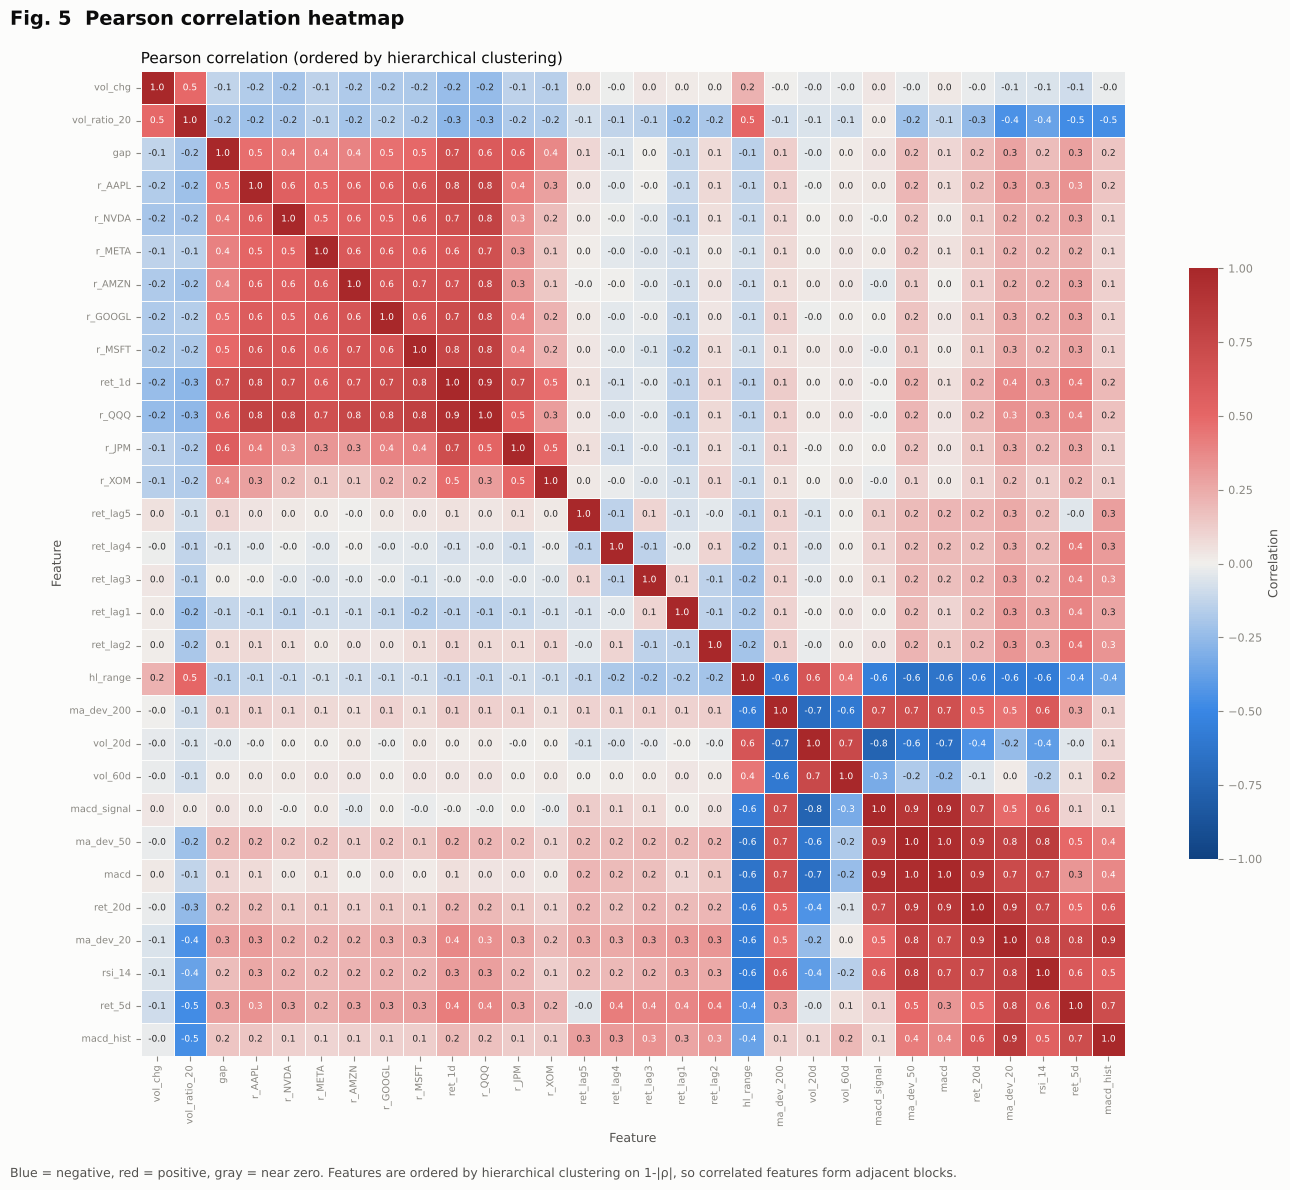

Saved: figures/05_corr_heatmap_pearson.png


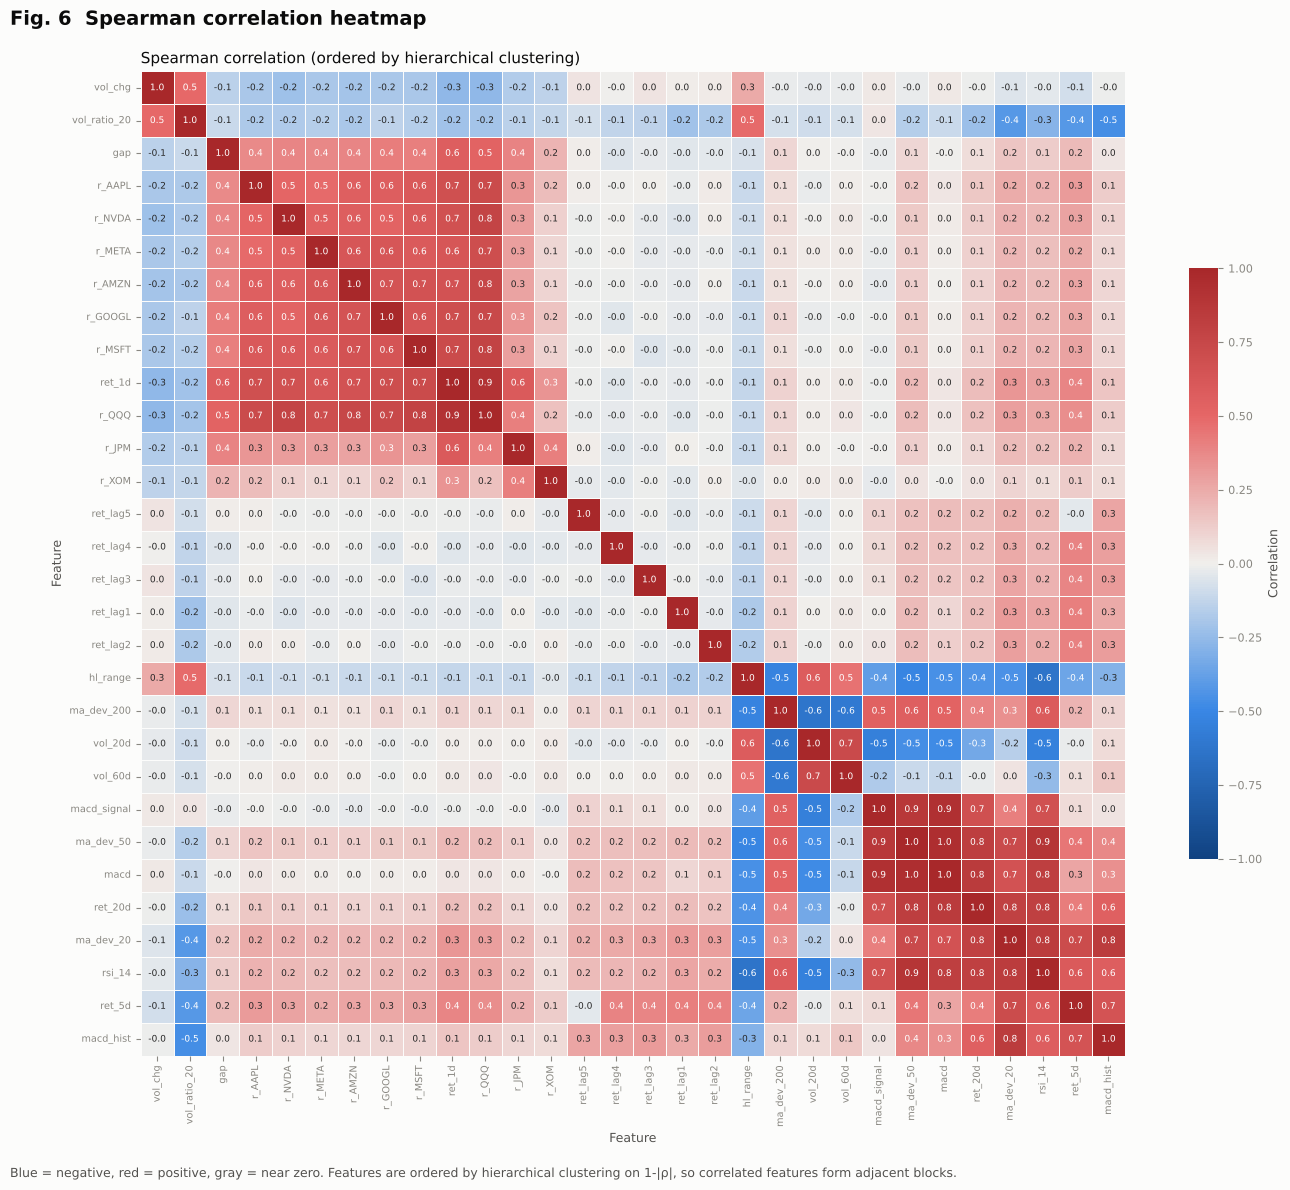

Saved: figures/06_corr_heatmap_spearman.png


In [14]:
X = data[FEATURES]
corr_p = X.corr(method="pearson")
corr_s = X.corr(method="spearman")

dist = (1 - corr_s.abs()).to_numpy(copy=True)
np.fill_diagonal(dist, 0)
Z = hierarchy.linkage(squareform(dist, checks=False), method="average")
order = [FEATURES[i] for i in hierarchy.leaves_list(Z)]


def corr_heatmap(cm, ax, title, annot=True, vlim=1.0):
    sns.heatmap(cm, ax=ax, cmap=DIVERGING, vmin=-vlim, vmax=vlim, center=0, square=True,
                annot=annot, fmt=".1f", annot_kws={"fontsize": 6.5},
                linewidths=0.4, linecolor=C["surface"], cbar_kws={"shrink": 0.6, "label": "Correlation"})
    ax.set_title(title, loc="left"); ax.set_xlabel("Feature"); ax.set_ylabel("Feature")
    ax.tick_params(labelsize=7); ax.grid(False)

for cm, name, label in [(corr_p, "05_corr_heatmap_pearson", "Pearson"), (corr_s, "06_corr_heatmap_spearman", "Spearman")]:
    fig, ax = plt.subplots(figsize=(14, 12))
    corr_heatmap(cm.loc[order, order], ax, f"{label} correlation (ordered by hierarchical clustering)")
    save(fig, name, f"Fig. {5 if label == 'Pearson' else 6}  {label} correlation heatmap",
         "Blue = negative, red = positive, gray = near zero. Features are ordered by hierarchical clustering on 1-|ρ|, so correlated features form adjacent blocks.")

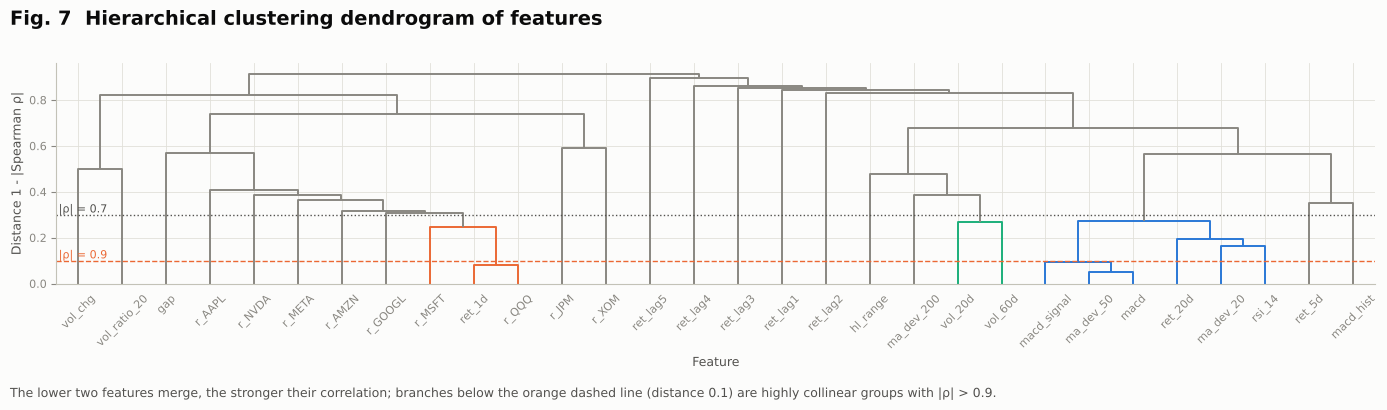

Saved: figures/07_corr_dendrogram.png


In [15]:
fig, ax = plt.subplots(figsize=(14, 4))
hierarchy.dendrogram(Z, labels=FEATURES, ax=ax, color_threshold=0.3, above_threshold_color=C["muted"], leaf_font_size=8)
ax.axhline(0.1, color=C["orange"], linestyle="--", linewidth=1); ax.text(0.5, 0.11, "|ρ| = 0.9", color=C["orange"], fontsize=8)
ax.axhline(0.3, color=C["ink2"], linestyle=":", linewidth=1); ax.text(0.5, 0.31, "|ρ| = 0.7", color=C["ink2"], fontsize=8)
ax.set_ylabel("Distance 1 - |Spearman ρ|"); ax.set_xlabel("Feature")
save(fig, "07_corr_dendrogram", "Fig. 7  Hierarchical clustering dendrogram of features",
     "The lower two features merge, the stronger their correlation; branches below the orange dashed line (distance 0.1) are highly collinear groups with |ρ| > 0.9.")

**Observation:** Features fall into three clear blocks. (1) A same-day return block: SPY's `ret_1d`, the 9 stocks' same-day returns and `gap` are all positively correlated — QQQ is the strongest (~0.94) and XOM the weakest (~0.48). (2) A trend/momentum block: `ma_dev_20/50/200`, `macd`, `macd_signal`, `macd_hist`, `rsi_14`, `ret_5d`, `ret_20d` are strongly positively correlated with each other. (3) A volatility block: `vol_20d`, `vol_60d`, `hl_range` are mutually positive and negatively correlated with the momentum block (volatility rises when prices fall). `vol_chg` and `vol_ratio_20` form their own small group, weakly negative with returns. The lagged returns `ret_lag1–5` are nearly uncorrelated with each other but mechanically overlap with `ret_5d`/`ret_20d` and the MA deviations. Pearson and Spearman structures are very similar; the few pairs that differ (e.g. `vol_20d` vs `macd_signal`: Pearson -0.75, Spearman -0.55) are driven by extreme values.

### 4.2 Strongly correlated pairs (|r| > 0.7)

In [16]:
def strong_pairs(cm_p, cm_s, thr):
    iu = np.triu_indices(len(FEATURES), k=1)
    out = pd.DataFrame({
        "feature_a": np.array(FEATURES)[iu[0]], "feature_b": np.array(FEATURES)[iu[1]],
        "pearson": cm_p.values[iu], "spearman": cm_s.values[iu],
    })
    out = out[(out.pearson.abs() > thr) | (out.spearman.abs() > thr)]
    return out.reindex(out.pearson.abs().sort_values(ascending=False).index).reset_index(drop=True)

pairs07 = strong_pairs(corr_p, corr_s, 0.7)
print(f"Pairs with |r| > 0.7 (Pearson or Spearman): {len(pairs07)}")
pairs07.round(3)

Pairs with |r| > 0.7 (Pearson or Spearman): 29


,feature_a,feature_b,pearson,spearman
0,ma_dev_50,macd,0.955,0.950
1,macd,macd_signal,0.949,0.933
2,ret_1d,r_QQQ,0.936,0.917
3,ma_dev_50,macd_signal,0.888,0.875
4,ret_20d,macd,0.879,0.844
5,ret_20d,ma_dev_50,0.862,0.821
6,ma_dev_20,macd_hist,0.861,0.836
7,ret_20d,ma_dev_20,0.853,0.803
8,ma_dev_50,rsi_14,0.830,0.891
9,r_MSFT,r_QQQ,0.808,0.784


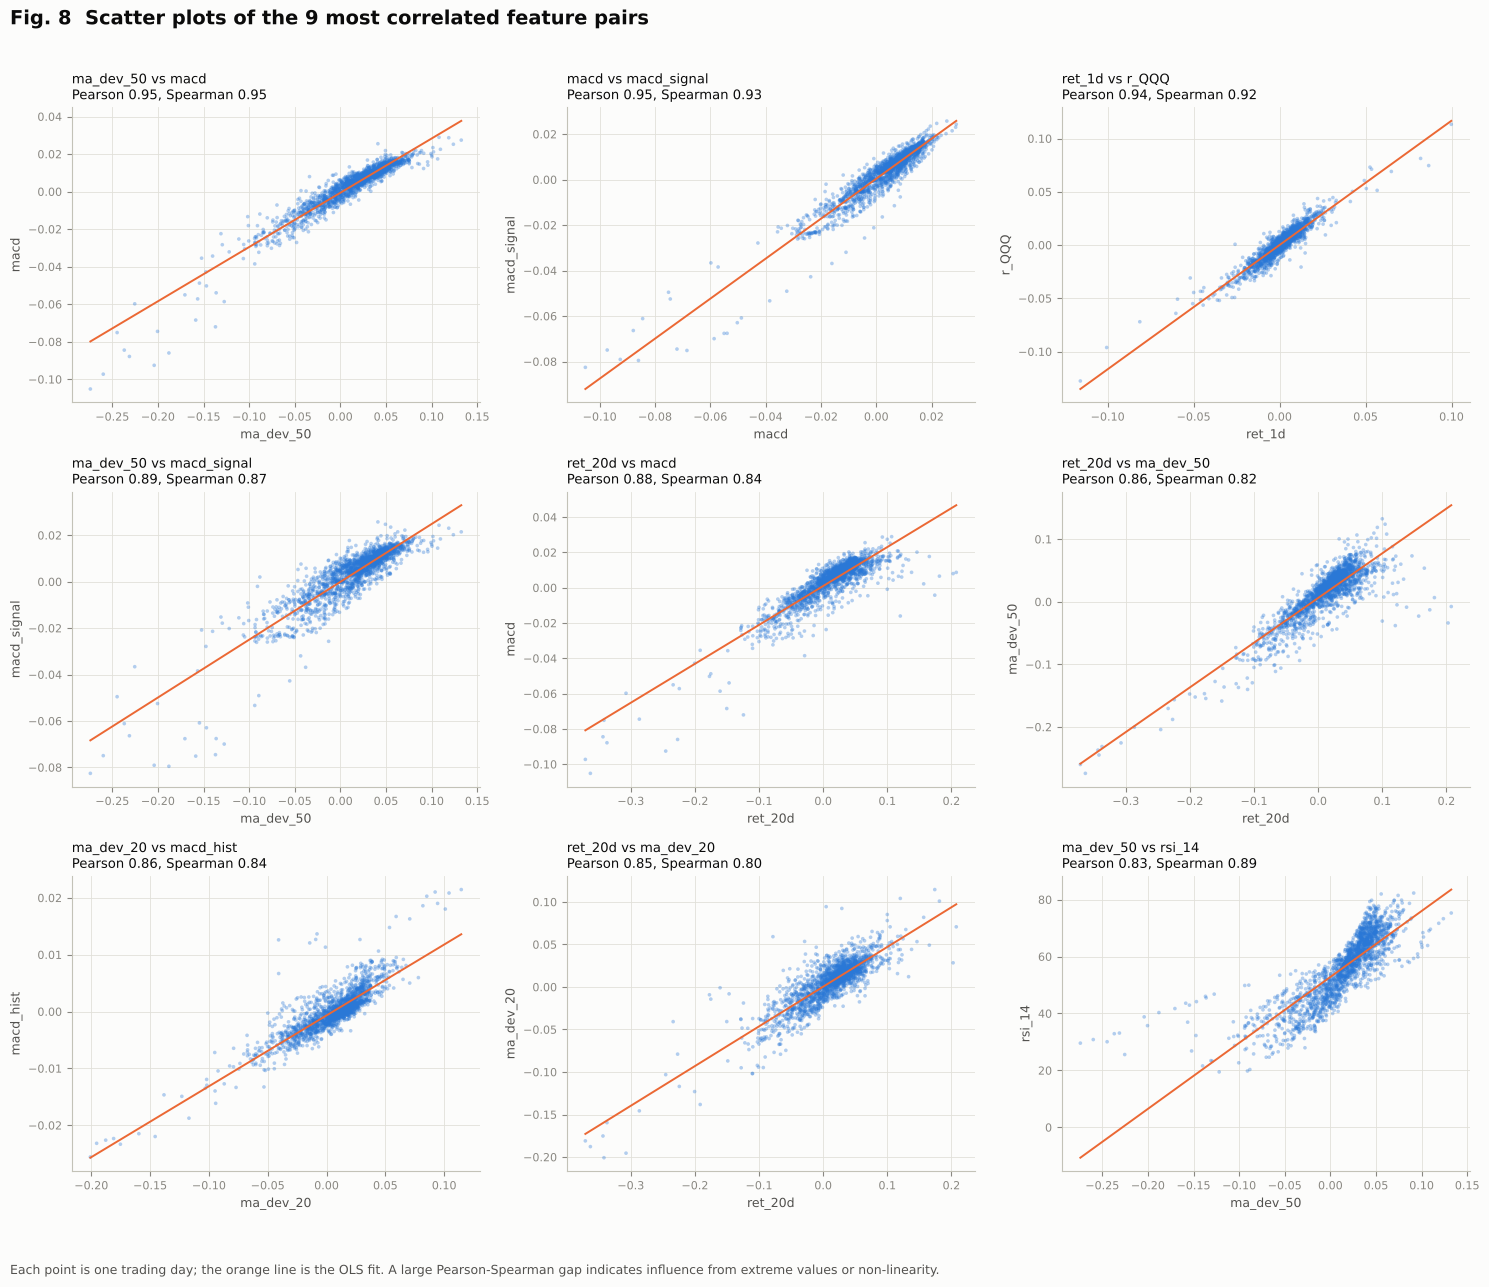

Saved: figures/08_top_pairs_scatter.png


In [17]:
top = pairs07.head(9)
fig, axes = plt.subplots(3, 3, figsize=(15, 13))
for ax, (_, row) in zip(axes.flat, top.iterrows()):
    a, b = row.feature_a, row.feature_b
    ax.scatter(data[a], data[b], s=7, alpha=0.35, color=C["blue"], edgecolor="none")
    m, c0 = np.polyfit(data[a], data[b], 1)
    xs = np.linspace(data[a].min(), data[a].max(), 50)
    ax.plot(xs, m * xs + c0, color=C["orange"], linewidth=1.4)
    ax.set_title(f"{a} vs {b}\nPearson {row.pearson:.2f}, Spearman {row.spearman:.2f}", loc="left", fontsize=9.5)
    ax.set_xlabel(a); ax.set_ylabel(b)
save(fig, "08_top_pairs_scatter", "Fig. 8  Scatter plots of the 9 most correlated feature pairs",
     "Each point is one trading day; the orange line is the OLS fit. A large Pearson-Spearman gap indicates influence from extreme values or non-linearity.")

**Observation:** 29 pairs satisfy |r| > 0.7, and most of them are 'mechanical' correlations due to overlapping definitions — e.g. MACD is essentially a difference of two moving averages, so it naturally tracks `ma_dev_50`; `ret_20d` and `ma_dev_20` both measure the past month's move. Genuine cross-asset strong correlations are limited to SPY–QQQ, SPY–MSFT/AAPL/GOOGL/JPM and the tech names vs. QQQ. In the scatter plots Pearson is generally a bit higher than Spearman, showing that extreme days (e.g. March 2020) inflate the linear correlation.

### 4.3 Highly collinear groups (|r| > 0.9)

In [18]:
pairs09 = strong_pairs(corr_p, corr_s, 0.9)
# Connected components using |r| > 0.9 as edges
parent = {f: f for f in FEATURES}
def find(x):
    while parent[x] != x:
        parent[x] = parent[parent[x]]; x = parent[x]
    return x
for a, b in zip(pairs09.feature_a, pairs09.feature_b):
    parent[find(a)] = find(b)
groups = {}
for f in FEATURES:
    groups.setdefault(find(f), []).append(f)
collinear_groups = [g for g in groups.values() if len(g) > 1]
print(f"Pairs with |r| > 0.9: {len(pairs09)}")
display(pairs09.round(3))
for i, g in enumerate(collinear_groups, 1):
    print(f"Collinear group {i}: {g}")

Pairs with |r| > 0.9: 3


,feature_a,feature_b,pearson,spearman
0,ma_dev_50,macd,0.955,0.950
1,macd,macd_signal,0.949,0.933
2,ret_1d,r_QQQ,0.936,0.917


Collinear group 1: ['ret_1d', 'r_QQQ']
Collinear group 2: ['ma_dev_50', 'macd', 'macd_signal']


**Observation:** Only two groups are highly collinear at |r| > 0.9: (1) {`ma_dev_50`, `macd`, `macd_signal`} — essentially the same medium-term trend information; (2) {`ret_1d`, `r_QQQ`} — SPY and QQQ move almost in lockstep on the same day. When modeling, keep one representative per group, e.g. `ma_dev_50` (or `macd`) and `ret_1d`. In addition, `ret_20d`, `ma_dev_20` and `rsi_14` correlate 0.8–0.9 with group (1); they are 'near-collinear', so watch for variance inflation in linear models.

### 4.4 Rolling correlation (60-day window)
Take the most correlated pairs from the full sample and add a few economically meaningful cross-asset / volume pairs,
then check whether each relationship is stable over time.

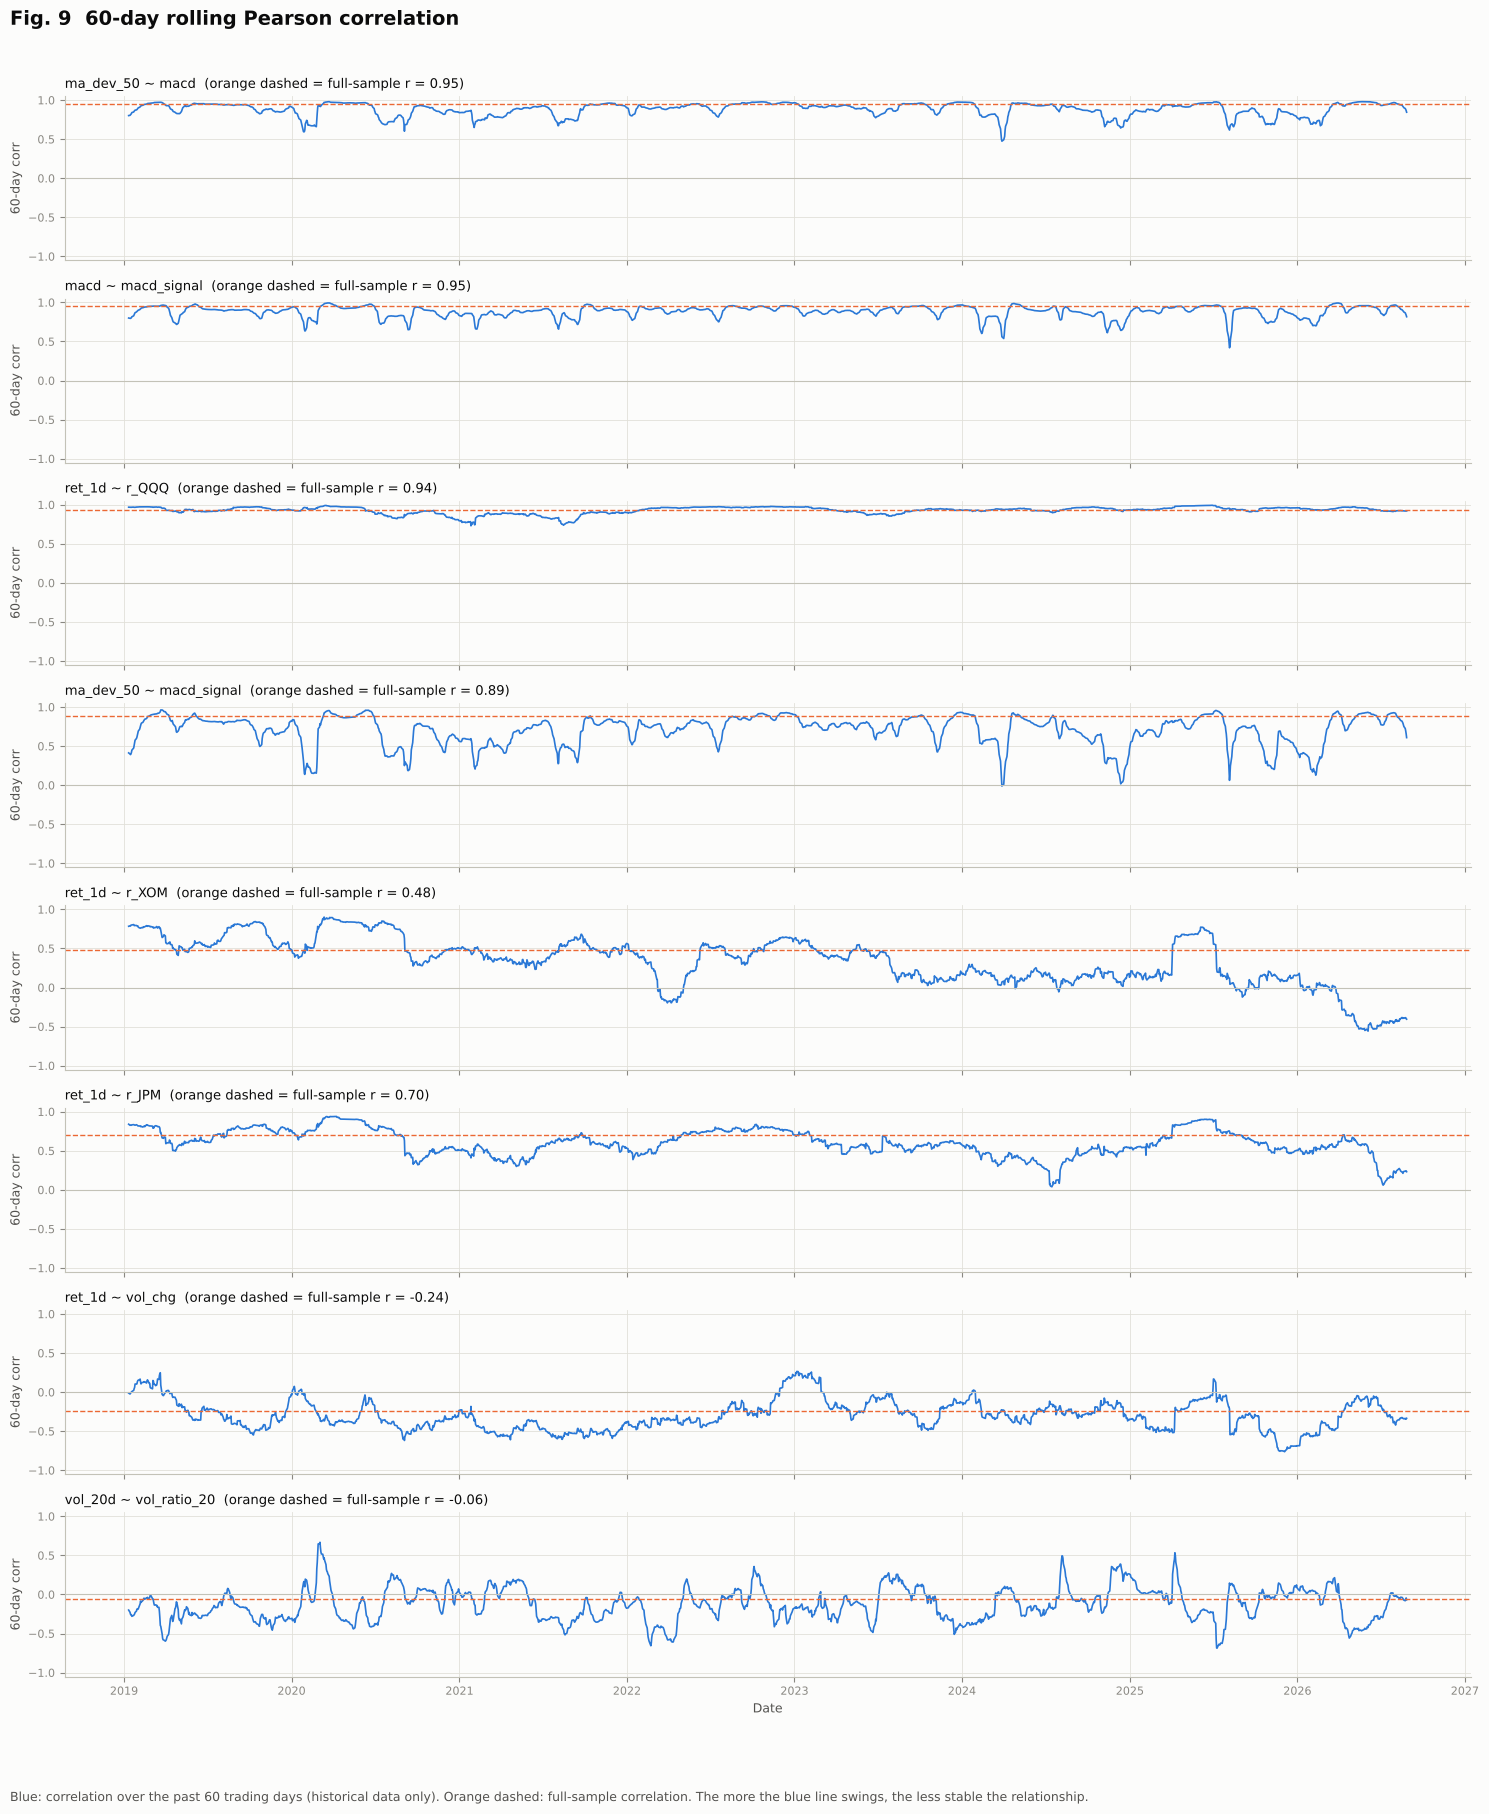

Saved: figures/09_rolling_correlation_60d.png


,full-sample r,rolling mean,rolling std,rolling min,rolling max
pair,,,,,
ma_dev_50 ~ macd,0.955,0.882,0.084,0.474,0.980
macd ~ macd_signal,0.949,0.883,0.073,0.420,0.994
ret_1d ~ r_QQQ,0.936,0.929,0.046,0.730,0.993
ma_dev_50 ~ macd_signal,0.888,0.706,0.190,-0.010,0.963
ret_1d ~ r_XOM,0.476,0.341,0.313,-0.558,0.902
ret_1d ~ r_JPM,0.702,0.602,0.170,0.039,0.939
ret_1d ~ vol_chg,-0.239,-0.295,0.190,-0.762,0.265
vol_20d ~ vol_ratio_20,-0.061,-0.123,0.211,-0.687,0.668


In [19]:
ROLL_PAIRS = [tuple(x) for x in pairs07[["feature_a", "feature_b"]].head(4).values]
for extra in [("ret_1d", "r_XOM"), ("ret_1d", "r_JPM"), ("ret_1d", "vol_chg"), ("vol_20d", "vol_ratio_20")]:
    if extra not in ROLL_PAIRS:
        ROLL_PAIRS.append(extra)

fig, axes = plt.subplots(len(ROLL_PAIRS), 1, figsize=(15, 2.3 * len(ROLL_PAIRS)), sharex=True)
roll_stats = []
for ax, (a, b) in zip(axes, ROLL_PAIRS):
    rc = data[a].rolling(60).corr(data[b])
    full = data[a].corr(data[b])
    roll_stats.append({"pair": f"{a} ~ {b}", "full-sample r": full, "rolling mean": rc.mean(), "rolling std": rc.std(),
                       "rolling min": rc.min(), "rolling max": rc.max()})
    ax.plot(rc.index, rc, color=C["blue"], linewidth=1.2)
    ax.axhline(full, color=C["orange"], linestyle="--", linewidth=1)
    ax.axhline(0, color=C["axis"], linewidth=0.8)
    ax.set_ylim(-1.05, 1.05); ax.set_ylabel("60-day corr")
    ax.set_title(f"{a} ~ {b}  (orange dashed = full-sample r = {full:.2f})", loc="left", fontsize=9.5)
axes[-1].set_xlabel("Date")
save(fig, "09_rolling_correlation_60d", "Fig. 9  60-day rolling Pearson correlation",
     "Blue: correlation over the past 60 trading days (historical data only). Orange dashed: full-sample correlation. The more the blue line swings, the less stable the relationship.")
pd.DataFrame(roll_stats).set_index("pair").round(3)

**Observation:** Definition-driven correlations (`ma_dev_50`~`macd`, `macd`~`macd_signal`) stay in the 0.8–1 range most of the time but periodically dip to 0.4–0.5 around trend reversals; `ma_dev_50`~`macd_signal` is even less stable and briefly falls near 0. SPY~QQQ is very stable (rolling range 0.73–0.99, std 0.05). SPY~JPM swings widely between 0.04 and 0.94. SPY~XOM is the least stable: around 0.8 in 2019–2020, near 0 from 2024 onward, and around -0.5 in 2026 — a structural change in how energy relates to the broad market. SPY~volume change is mostly negative but turns positive at times; `vol_20d`~`vol_ratio_20` flips between roughly ±0.6, so its full-sample correlation (-0.06) is not representative.

### 4.5 Correlation by market regime: high vs. low volatility
Regime: day t is "high vol" if `vol_20d` exceeds its **expanding-window median up to day t** (minimum 252 days), otherwise "low vol".
The threshold uses only historical information, avoiding the look-ahead bias of a full-sample median.

low vol     1000
high vol     904
Name: count, dtype: int64


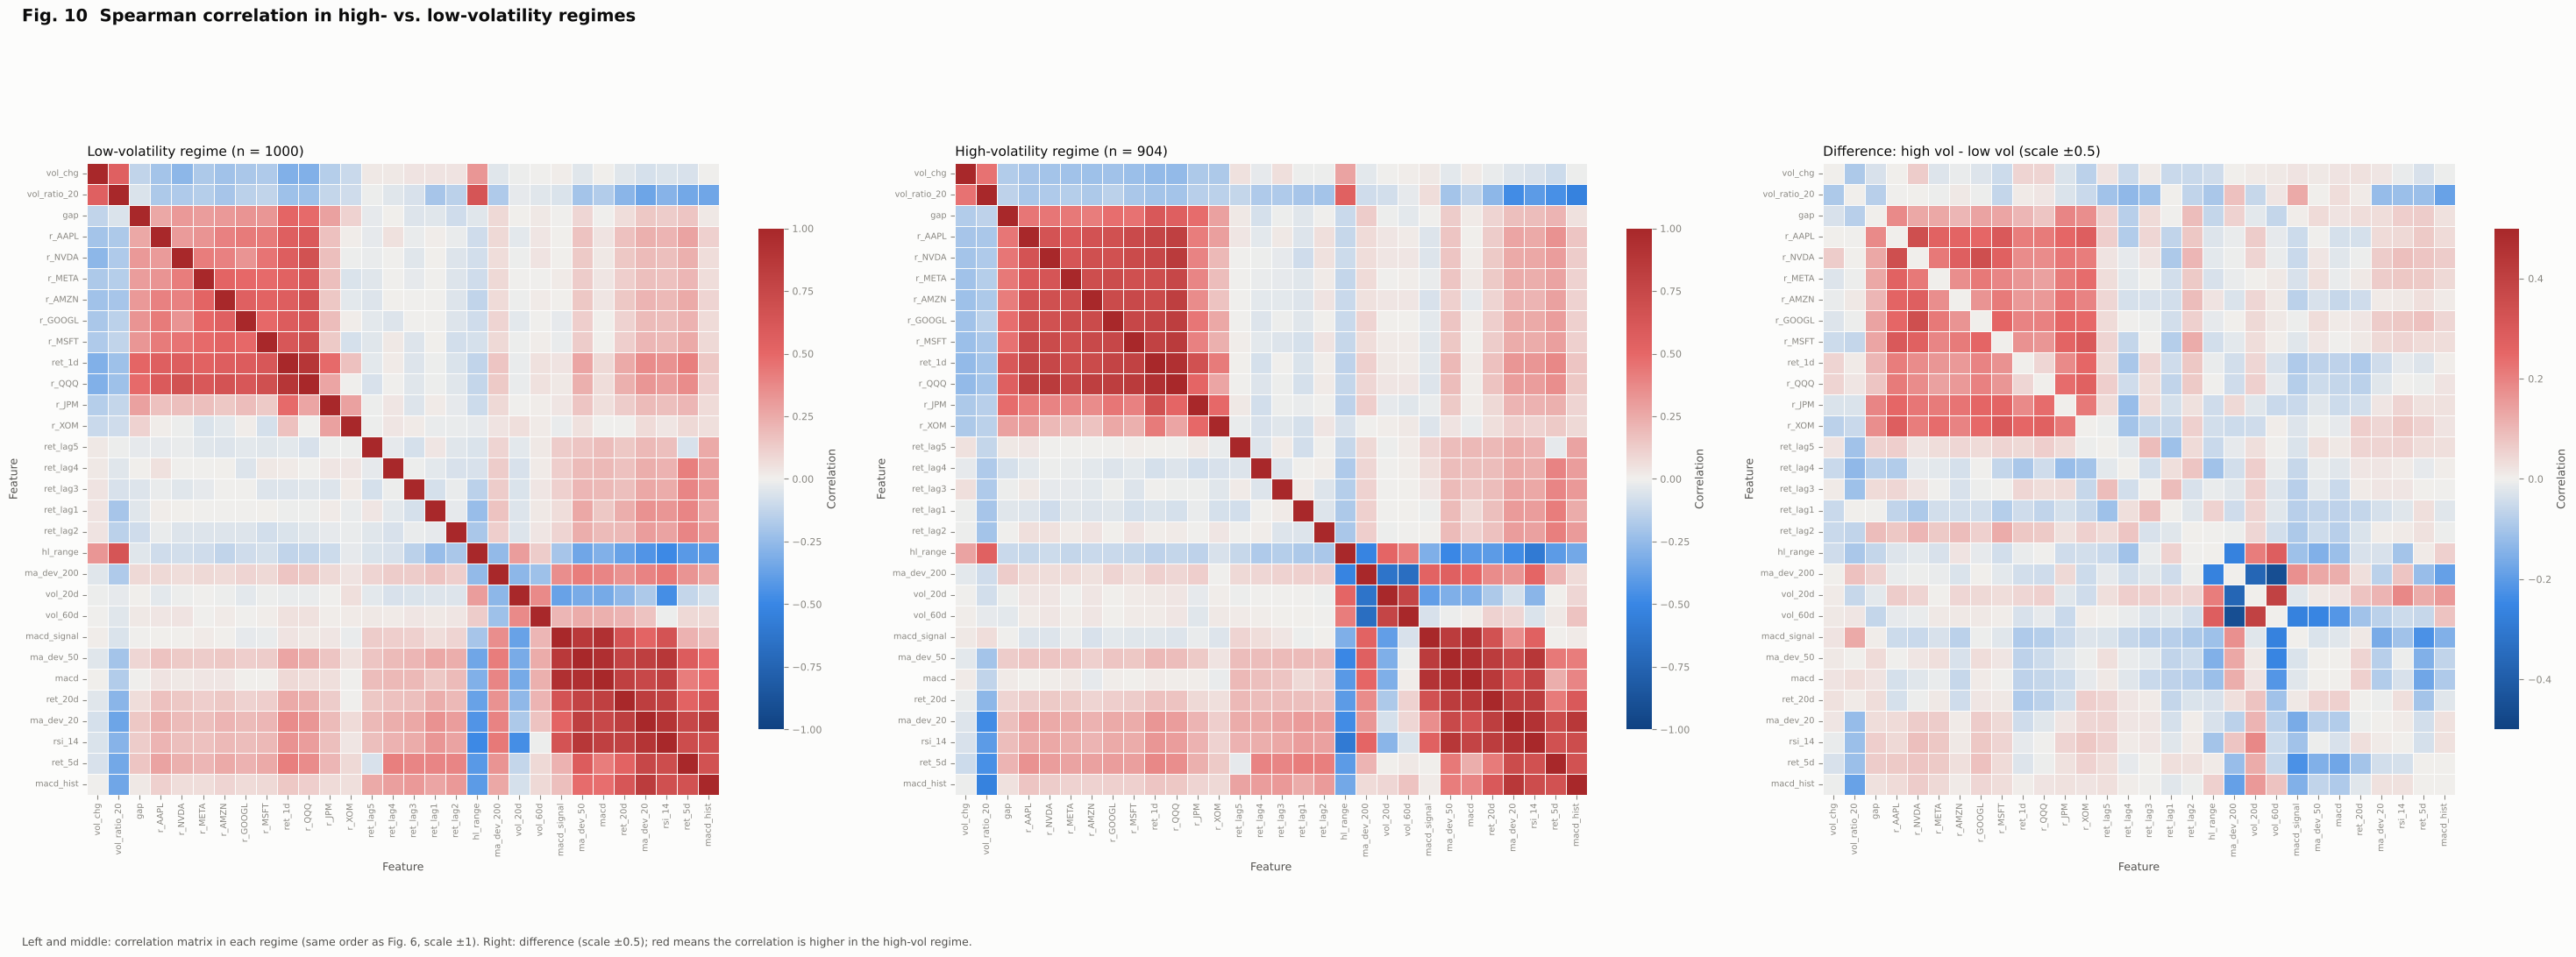

Saved: figures/10_corr_by_volatility_regime.png


,feature_a,feature_b,low vol,high vol,difference
381,ma_dev_200,vol_60d,-0.220,-0.675,-0.455
390,vol_20d,vol_60d,0.373,0.769,0.396
380,ma_dev_200,vol_20d,-0.270,-0.637,-0.368
84,r_AAPL,r_NVDA,0.311,0.656,0.345
112,r_NVDA,r_GOOGL,0.330,0.675,0.345
88,r_AAPL,r_MSFT,0.426,0.730,0.303
207,r_MSFT,r_XOM,-0.076,0.227,0.303
371,hl_range,vol_60d,0.130,0.415,0.285
92,r_AAPL,r_XOM,0.009,0.293,0.284
111,r_NVDA,r_AMZN,0.402,0.682,0.280


In [20]:
exp_med = feat["vol_20d"].expanding(min_periods=252).median().reindex(data.index)
regime = pd.Series(np.where(data["vol_20d"] > exp_med, "high vol", "low vol"), index=data.index).where(exp_med.notna())
print(regime.value_counts())

corr_hi = data.loc[regime == "high vol", FEATURES].corr(method="spearman").loc[order, order]
corr_lo = data.loc[regime == "low vol", FEATURES].corr(method="spearman").loc[order, order]
fig, axes = plt.subplots(1, 3, figsize=(30, 11))
corr_heatmap(corr_lo, axes[0], f"Low-volatility regime (n = {(regime == 'low vol').sum()})", annot=False)
corr_heatmap(corr_hi, axes[1], f"High-volatility regime (n = {(regime == 'high vol').sum()})", annot=False)
corr_heatmap(corr_hi - corr_lo, axes[2], "Difference: high vol - low vol (scale ±0.5)", annot=False, vlim=0.5)
save(fig, "10_corr_by_volatility_regime", "Fig. 10  Spearman correlation in high- vs. low-volatility regimes",
     "Left and middle: correlation matrix in each regime (same order as Fig. 6, scale ±1). Right: difference (scale ±0.5); red means the correlation is higher in the high-vol regime.")

diff = (corr_hi - corr_lo)
iu = np.triu_indices(len(order), k=1)
regime_diff = pd.DataFrame({"feature_a": np.array(order)[iu[0]], "feature_b": np.array(order)[iu[1]],
                            "low vol": corr_lo.values[iu], "high vol": corr_hi.values[iu], "difference": diff.values[iu]})
regime_diff.reindex(regime_diff["difference"].abs().sort_values(ascending=False).index).head(12).round(3)

**Observation:** In the high-volatility regime, correlations among stocks and between stocks and SPY are broadly higher — e.g. AAPL~NVDA rises from 0.31 to 0.66 and AAPL~MSFT from 0.43 to 0.73 — the classic 'correlations go to one in a crisis' effect, which reduces diversification. XOM is essentially uncorrelated with tech in calm periods (~0) but rises to 0.2–0.3 in volatile periods. The volatility block also changes: in high vol, `vol_20d`~`vol_60d` rises from 0.37 to 0.77, and the negative link between `ma_dev_200` and volatility deepens from about -0.25 to about -0.65 (in bear markets, 'the deeper the drawdown, the higher the volatility' is much stronger). The full-sample correlation matrix hides this regime dependence.

### 4.6 Lead-lag relationships: cross-correlation (CCF)
At lag k the CCF is corr(x_{t+k}, y_t): a significant value at k > 0 means **y leads x**; at k < 0 it means **x leads y**.
Dashed lines are the approximate 95% band ±1.96/√n (assumes white noise, which is too narrow for volatility-clustered series — interpret conservatively).

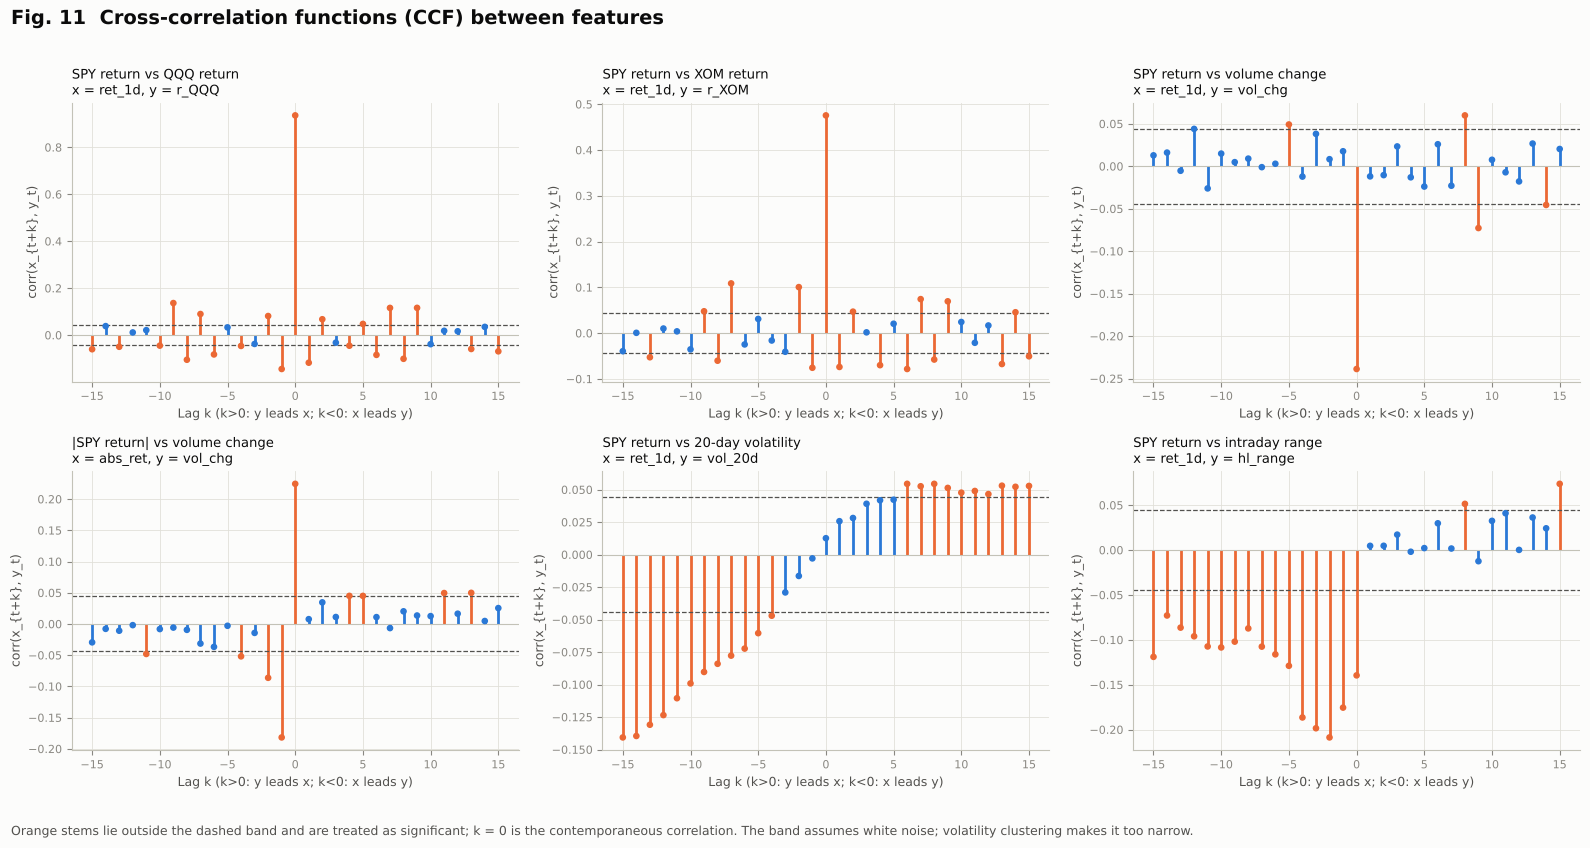

Saved: figures/11_cross_correlation.png


,x,y,k,ccf
0,ret_1d,r_QQQ,-4,-0.046
1,ret_1d,r_QQQ,-2,0.081
2,ret_1d,r_QQQ,-1,-0.144
3,ret_1d,r_QQQ,1,-0.118
4,ret_1d,r_QQQ,2,0.068
5,ret_1d,r_QQQ,4,-0.045
6,ret_1d,r_QQQ,5,0.048
7,ret_1d,r_XOM,-2,0.101
8,ret_1d,r_XOM,-1,-0.076
9,ret_1d,r_XOM,1,-0.074


In [21]:
CCF_PAIRS = [
    ("ret_1d", "r_QQQ", "SPY return vs QQQ return"),
    ("ret_1d", "r_XOM", "SPY return vs XOM return"),
    ("ret_1d", "vol_chg", "SPY return vs volume change"),
    ("abs_ret", "vol_chg", "|SPY return| vs volume change"),
    ("ret_1d", "vol_20d", "SPY return vs 20-day volatility"),
    ("ret_1d", "hl_range", "SPY return vs intraday range"),
]
ccf_data = data.assign(abs_ret=data["ret_1d"].abs())
MAXLAG = 15
lags = np.arange(-MAXLAG, MAXLAG + 1)


def ccf_two_sided(x, y, maxlag):
    """Return corr(x_{t+k}, y_t) for k = -maxlag..maxlag."""
    x = (x - x.mean()) / x.std(); y = (y - y.mean()) / y.std()
    return np.array([x.shift(-k).corr(y) for k in range(-maxlag, maxlag + 1)])

fig, axes = plt.subplots(2, 3, figsize=(16, 8.5))
band = 1.96 / np.sqrt(len(ccf_data))
ccf_tbl = []
for ax, (a, b, title) in zip(axes.flat, CCF_PAIRS):
    vals = ccf_two_sided(ccf_data[a], ccf_data[b], MAXLAG)
    col = [C["orange"] if abs(v) > band else C["blue"] for v in vals]
    ax.vlines(lags, 0, vals, color=col, linewidth=2)
    ax.scatter(lags, vals, color=col, s=14, zorder=3)
    ax.axhline(band, color=C["ink2"], linestyle="--", linewidth=0.9); ax.axhline(-band, color=C["ink2"], linestyle="--", linewidth=0.9)
    ax.axhline(0, color=C["axis"], linewidth=0.8)
    ax.set_title(f"{title}\nx = {a}, y = {b}", loc="left", fontsize=9.5)
    ax.set_xlabel("Lag k (k>0: y leads x; k<0: x leads y)"); ax.set_ylabel("corr(x_{t+k}, y_t)")
    for k, v in zip(lags, vals):
        if k != 0 and abs(k) <= 5 and abs(v) > band:
            ccf_tbl.append({"x": a, "y": b, "k": k, "ccf": v})
save(fig, "11_cross_correlation", "Fig. 11  Cross-correlation functions (CCF) between features",
     "Orange stems lie outside the dashed band and are treated as significant; k = 0 is the contemporaneous correlation. The band assumes white noise; volatility clustering makes it too narrow.")
pd.DataFrame(ccf_tbl).round(3)

**Observation:** Contemporaneous (k=0) relationships dominate: SPY vs QQQ (0.94), SPY vs XOM (0.48), and |return| vs volume change (+0.22: big-move days come with higher volume). Three lead-lag patterns look credible: (1) past `ret_1d` is significantly negatively correlated with current `hl_range` and `vol_20d` at k<0 (about -0.1 to -0.2): past declines lead future increases in volatility (consistent with the leverage effect); the positive values at k>0 are weak (~+0.05). (2) |ret| at k=-1 is negatively correlated with `vol_chg` (~-0.18): volume falls back the day after a big move (volume mean reversion). (3) The ±0.1 spikes at non-zero lags for SPY vs QQQ and XOM mirror the saw-tooth pattern of SPY's own ACF (Fig. 15, mostly from 2020), so they are more likely spurious lead-lag transmitted through autocorrelation than genuine leadership; a proper test would require prewhitening first.

## 5. Features vs. next-day direction

### 5.1 Box plots grouped by next-day up/down
Each feature is split by `y`, annotated with the Mann-Whitney U test p-value (do the two groups differ in location?).
Since 30 features are tested at once, the Bonferroni-corrected threshold 0.05/30 ≈ 0.0017 is also shown.

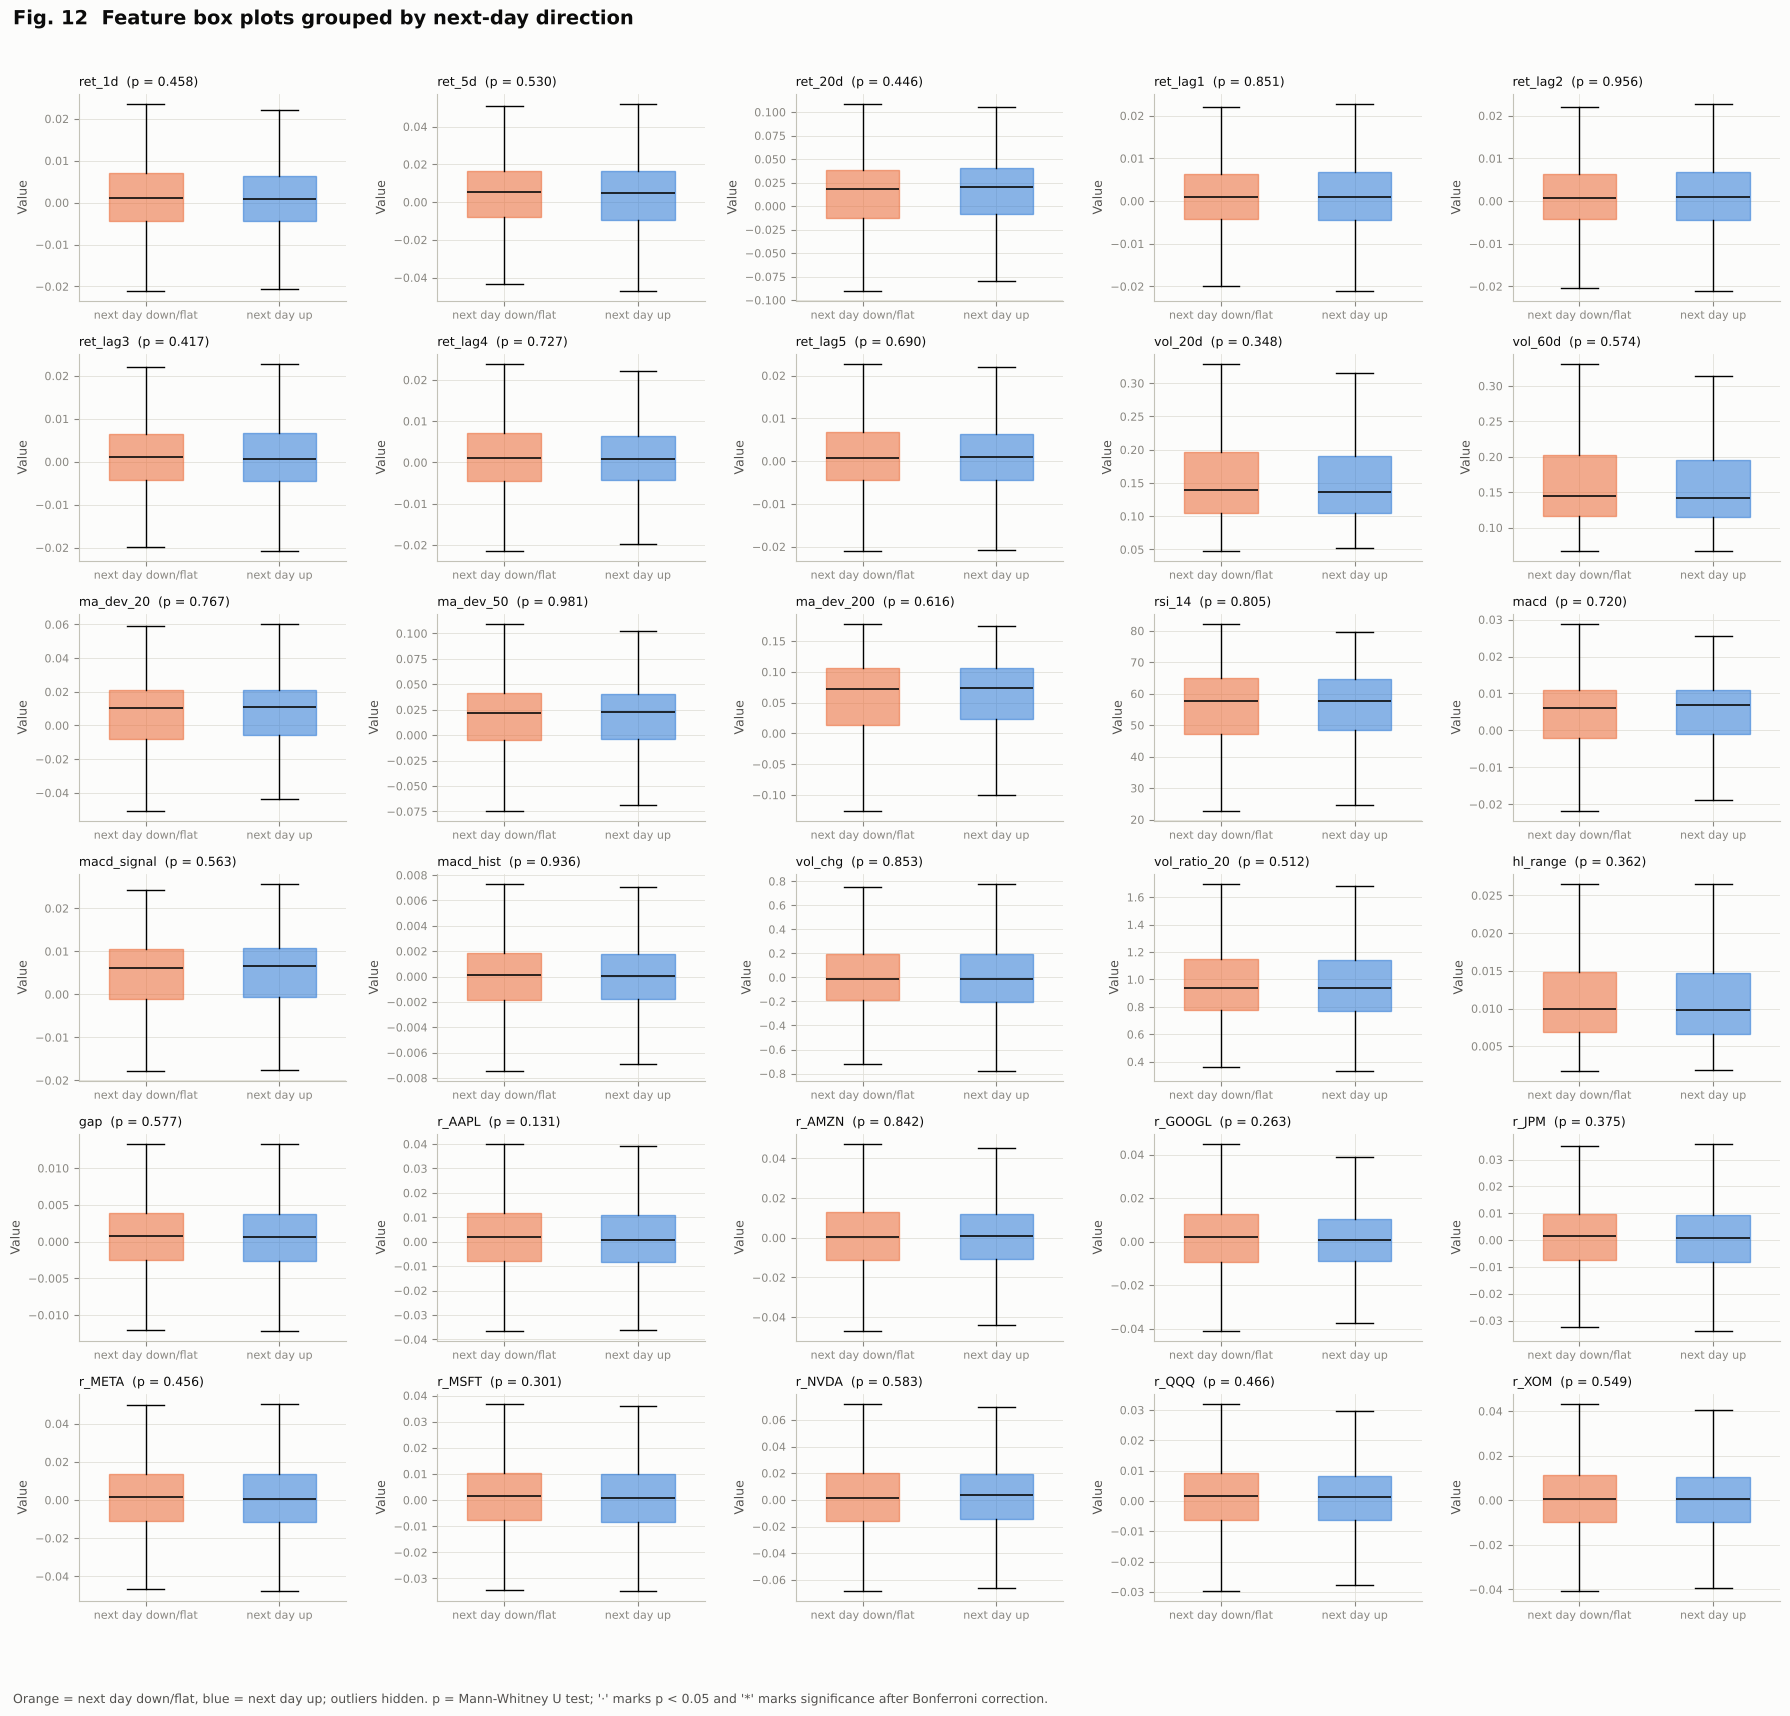

Saved: figures/12_features_by_next_day_direction.png


,median (up),median (down),MW p-value
feature,,,
r_AAPL,0.0006,0.0018,0.1314
r_GOOGL,0.0009,0.0020,0.2634
r_MSFT,0.0007,0.0014,0.3008
vol_20d,0.1363,0.1388,0.3483
hl_range,0.0098,0.0100,0.3623
r_JPM,0.0007,0.0014,0.3753
ret_lag3,0.0007,0.0012,0.4173
ret_20d,0.0206,0.0187,0.4459
r_META,0.0004,0.0015,0.4560


In [22]:
up, down = data[data.y == 1], data[data.y == 0]
mw = []
fig, axes = plt.subplots(nrow, ncol, figsize=(18, 2.9 * nrow))
for ax, f in zip(axes.flat, FEATURES):
    p = stats.mannwhitneyu(up[f], down[f]).pvalue
    mw.append((f, up[f].median(), down[f].median(), p))
    bp = ax.boxplot([down[f], up[f]], tick_labels=["next day down/flat", "next day up"], widths=0.55, showfliers=False,
                    patch_artist=True, medianprops={"color": C["ink"], "linewidth": 1.2})
    for patch, colr in zip(bp["boxes"], [UP_DOWN[0], UP_DOWN[1]]):
        patch.set_facecolor(colr); patch.set_alpha(0.55); patch.set_edgecolor(colr)
    star = " *" if p < 0.05 / len(FEATURES) else (" ·" if p < 0.05 else "")
    ax.set_title(f"{f}  (p = {p:.3f}{star})", fontsize=9, loc="left")
    ax.set_ylabel("Value")
for ax in axes.flat[len(FEATURES):]:
    ax.axis("off")
save(fig, "12_features_by_next_day_direction", "Fig. 12  Feature box plots grouped by next-day direction",
     "Orange = next day down/flat, blue = next day up; outliers hidden. p = Mann-Whitney U test; '·' marks p < 0.05 and '*' marks significance after Bonferroni correction.")
mw_tbl = pd.DataFrame(mw, columns=["feature", "median (up)", "median (down)", "MW p-value"]).set_index("feature").sort_values("MW p-value")
mw_tbl.head(10).round(4)

**Observation:** For all 30 features the up and down groups overlap almost completely. The smallest Mann-Whitney p-value is 0.13 (`r_AAPL`); no feature is significant at 5%, let alone after Bonferroni correction. In other words, no single feature shows a location difference between next-day up and down days. Note that 55.3% of next days in the sample are up, so there is a sizeable 'up' base rate.

### 5.2 Correlation of each feature with the next-day return (ranked)

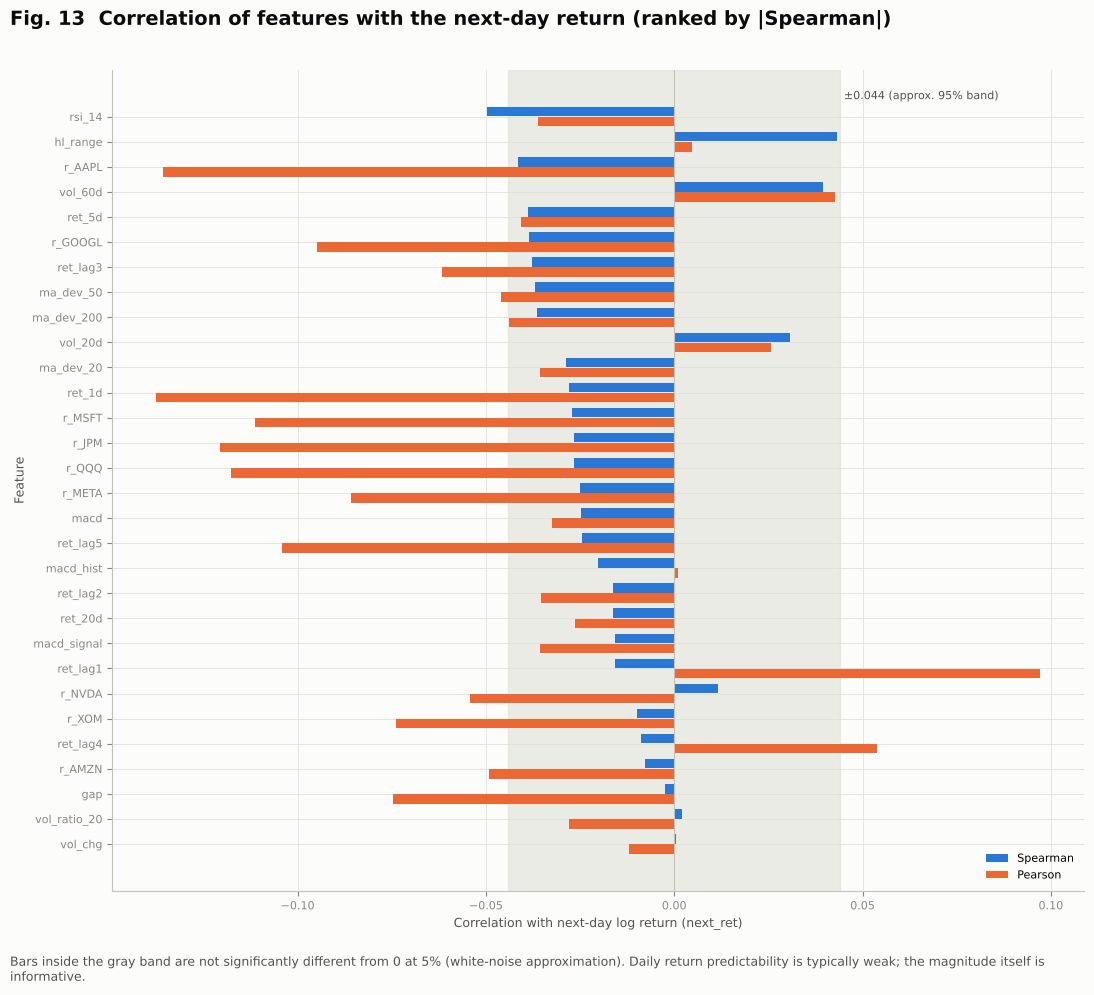

Saved: figures/13_corr_with_next_return.png


,pearson,spearman
rsi_14,-0.0361,-0.0497
hl_range,0.0047,0.0433
r_AAPL,-0.1358,-0.0414
vol_60d,0.0426,0.0396
ret_5d,-0.0407,-0.0388
r_GOOGL,-0.0949,-0.0385
ret_lag3,-0.0615,-0.0378
ma_dev_50,-0.0459,-0.0369
ma_dev_200,-0.0439,-0.0364
vol_20d,0.0258,0.0306


In [23]:
rel = pd.DataFrame({
    "pearson": data[FEATURES].corrwith(data["next_ret"], method="pearson"),
    "spearman": data[FEATURES].corrwith(data["next_ret"], method="spearman"),
})
rel = rel.reindex(rel["spearman"].abs().sort_values(ascending=True).index)
band = 1.96 / np.sqrt(len(data))

fig, ax = plt.subplots(figsize=(11, 10))
yy = np.arange(len(rel))
ax.barh(yy + 0.2, rel["spearman"], height=0.38, color=C["blue"], label="Spearman")
ax.barh(yy - 0.2, rel["pearson"], height=0.38, color=C["orange"], label="Pearson")
ax.axvspan(-band, band, color=C["grid"], alpha=0.6, zorder=0)
ax.text(band, len(rel) - 0.3, f" ±{band:.3f} (approx. 95% band)", fontsize=8, color=C["ink2"])
ax.axvline(0, color=C["axis"], linewidth=0.8)
ax.set_yticks(yy, rel.index); ax.set_xlabel("Correlation with next-day log return (next_ret)"); ax.set_ylabel("Feature")
ax.legend(loc="lower right")
save(fig, "13_corr_with_next_return", "Fig. 13  Correlation of features with the next-day return (ranked by |Spearman|)",
     "Bars inside the gray band are not significantly different from 0 at 5% (white-noise approximation). Daily return predictability is typically weak; the magnitude itself is informative.")
rel.sort_values("spearman", key=np.abs, ascending=False).round(4).head(12)

**Observation:** Correlations with the next-day return are all weak. The largest |Spearman ρ| is `rsi_14` (-0.050), just outside the ±0.044 band, followed by `hl_range` (+0.043), `r_AAPL` (-0.041), `vol_60d` (+0.040) and `ret_5d` (-0.039), all at the edge of the band. Together they point to 'weak mean reversion + slightly higher returns after high volatility': after strong recent gains (high RSI / MA deviation) the next day is slightly weaker, and after high volatility it is slightly stronger. Features with a large Pearson–Spearman gap (`ret_1d` -0.14 vs -0.03; `r_AAPL` -0.14 vs -0.04; `r_GOOGL` -0.09 vs -0.04) show that their linear correlation is driven by a handful of extreme reversal days (March 2020) and does not generalize.

### 5.3 Mutual information (captures non-linear relationships)
Mutual information is computed between each feature and `y` (classification) and `next_ret` (regression).
MI estimates are biased upward in finite samples, so a **permutation baseline** is added: the label is shuffled 30 times and the 95th percentile of the shuffled MI is used as a "noise level" reference line.

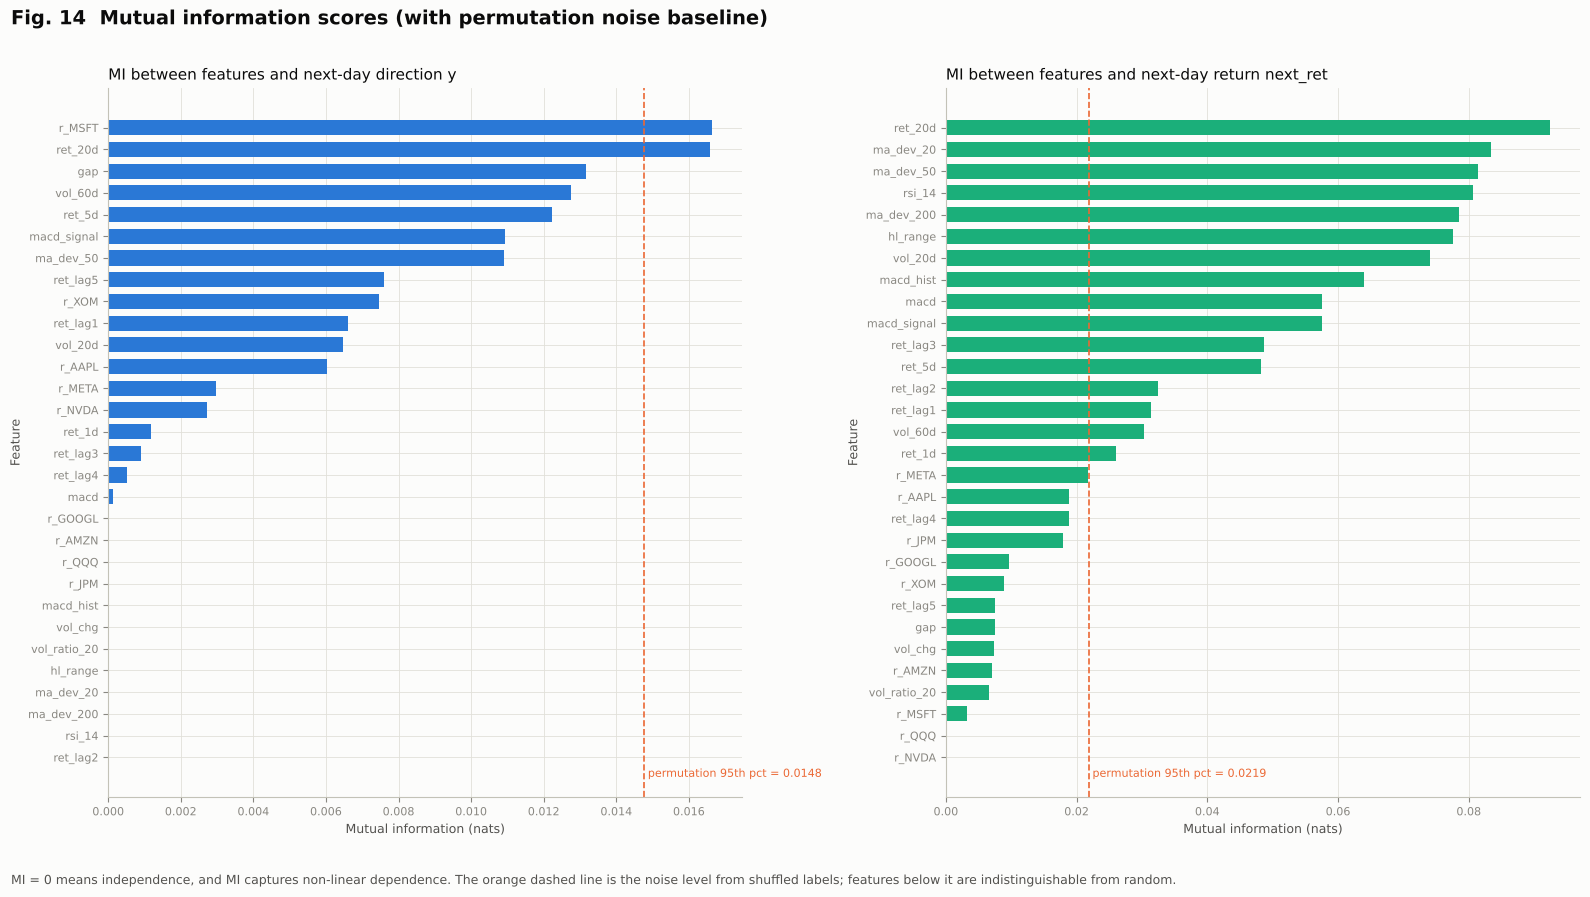

Saved: figures/14_mutual_information.png


,MI(y),MI(next_ret),above_null_y,above_null_r
ret_20d,0.0166,0.0924,True,True
ma_dev_20,0.0000,0.0834,False,True
ma_dev_50,0.0109,0.0814,False,True
rsi_14,0.0000,0.0806,False,True
ma_dev_200,0.0000,0.0786,False,True
hl_range,0.0000,0.0776,False,True
vol_20d,0.0065,0.0741,False,True
macd_hist,0.0000,0.0639,False,True
macd,0.0001,0.0576,False,True
macd_signal,0.0109,0.0575,False,True


In [24]:
Xmi = data[FEATURES].values
mi_y = mutual_info_classif(Xmi, data["y"].astype(int), random_state=SEED, n_neighbors=5)
mi_r = mutual_info_regression(Xmi, data["next_ret"], random_state=SEED, n_neighbors=5)

rng = np.random.default_rng(SEED)
null_y, null_r = [], []
for i in range(30):
    perm = rng.permutation(len(data))
    null_y.append(mutual_info_classif(Xmi, data["y"].astype(int).values[perm], random_state=i, n_neighbors=5))
    null_r.append(mutual_info_regression(Xmi, data["next_ret"].values[perm], random_state=i, n_neighbors=5))
thr_y = np.quantile(np.concatenate(null_y), 0.95)
thr_r = np.quantile(np.concatenate(null_r), 0.95)

mi = pd.DataFrame({"MI(y)": mi_y, "MI(next_ret)": mi_r}, index=FEATURES)
fig, axes = plt.subplots(1, 2, figsize=(16, 9))
for ax, col, thr, colr in [(axes[0], "MI(y)", thr_y, C["blue"]), (axes[1], "MI(next_ret)", thr_r, C["aqua"])]:
    m = mi[col].sort_values()
    ax.barh(m.index, m.values, color=colr, height=0.7)
    ax.axvline(thr, color=C["orange"], linestyle="--", linewidth=1.2)
    ax.text(thr, -0.9, f" permutation 95th pct = {thr:.4f}", color=C["orange"], fontsize=8)
    ax.set_xlabel("Mutual information (nats)"); ax.set_ylabel("Feature")
    ax.set_title(f"MI between features and {'next-day direction y' if col == 'MI(y)' else 'next-day return next_ret'}", loc="left")
save(fig, "14_mutual_information", "Fig. 14  Mutual information scores (with permutation noise baseline)",
     "MI = 0 means independence, and MI captures non-linear dependence. The orange dashed line is the noise level from shuffled labels; features below it are indistinguishable from random.")
mi.assign(above_null_y=mi["MI(y)"] > thr_y, above_null_r=mi["MI(next_ret)"] > thr_r).sort_values("MI(next_ret)", ascending=False).round(4)

**Decomposing the mutual information**: do the features with high `MI(next_ret)` carry information about **direction** or about **magnitude**?
Compare their Spearman correlation with `|next_ret|` (next-day move size) and with `y` (direction).

In [25]:
decomp = pd.DataFrame({
    "MI(next_ret)": mi["MI(next_ret)"],
    "ρ(feature, |next_ret|)": data[FEATURES].corrwith(data["next_ret"].abs(), method="spearman"),
    "ρ(feature, y)": data[FEATURES].corrwith(data["y"], method="spearman"),
}).sort_values("MI(next_ret)", ascending=False)
decomp.head(12).round(4)

,MI(next_ret),"ρ(feature, |next_ret|)","ρ(feature, y)"
ret_20d,0.0924,-0.2632,0.0172
ma_dev_20,0.0834,-0.2985,0.0067
ma_dev_50,0.0814,-0.3114,0.0005
rsi_14,0.0806,-0.3821,0.0055
ma_dev_200,0.0786,-0.3042,0.0113
hl_range,0.0776,0.3603,-0.0205
vol_20d,0.0741,0.3078,-0.0211
macd_hist,0.0639,-0.1925,0.0018
macd,0.0576,-0.2766,0.0081
macd_signal,0.0575,-0.2311,0.0130


**Observation:** MI with the next-day direction `y` is below the permutation noise baseline for almost every feature; only `r_MSFT` and `ret_20d` barely exceed it, which, with 30 features compared at once, is consistent with chance — no feature carries reliable directional information. For MI with `next_ret`, 16 features are clearly above the noise baseline (highest: `ret_20d`, MA deviations, `rsi_14`, `hl_range`, `vol_20d`). However, the decomposition table shows these features have Spearman correlations of 0.26–0.38 (in absolute value) with |next_ret| (next-day move size) but ≈0 with direction `y`. In other words, the non-linear dependence captured by MI is mainly about **predicting the size of the next day's move**, not its direction.

### 5.4 ACF / PACF of returns

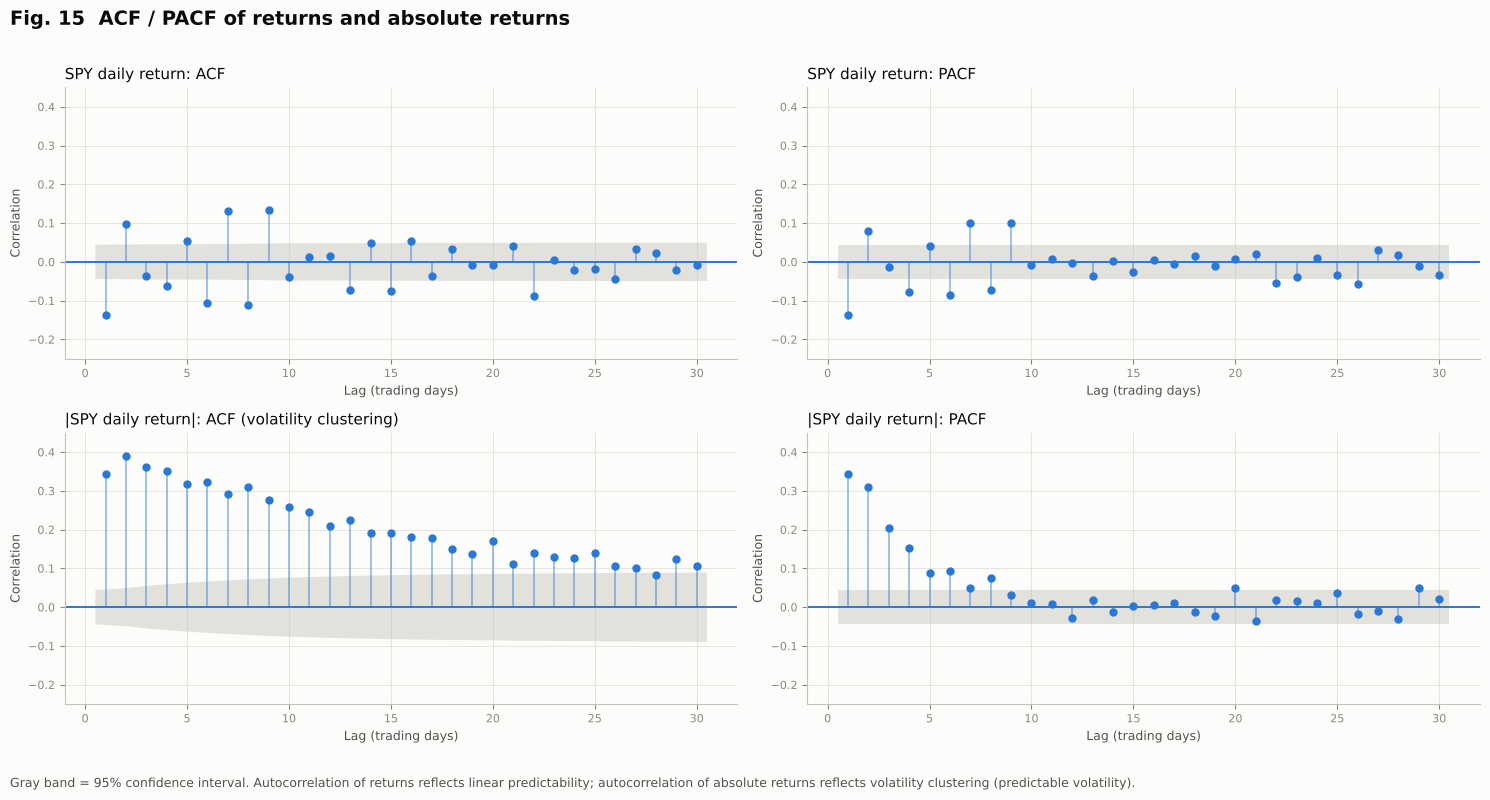

Saved: figures/15_returns_acf_pacf.png


lb_stat  lb_pvalue
ret_1d   5     71.3354        0.0
         10   191.1765        0.0
         20   229.2094        0.0
|ret_1d| 5   1240.0590        0.0
         10  2091.1586        0.0
         20  2814.5033        0.0

Approx. 95% band: ± 0.047


,full-sample ACF,ACF excl. 2020,full-sample rank ACF
lag1,-0.137,-0.030,-0.028
lag2,0.097,-0.010,-0.016
lag3,-0.036,-0.047,-0.017
lag4,-0.061,-0.029,-0.037
lag5,0.053,-0.006,-0.010


In [26]:
r = data["ret_1d"]
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
for ax, (fn, series, title) in zip(axes.flat, [
        (plot_acf, r, "SPY daily return: ACF"), (plot_pacf, r, "SPY daily return: PACF"),
        (plot_acf, r.abs(), "|SPY daily return|: ACF (volatility clustering)"), (plot_pacf, r.abs(), "|SPY daily return|: PACF")]):
    kw = {"method": "ywm"} if fn is plot_pacf else {}
    fn(series, lags=30, ax=ax, zero=False, color=C["blue"], vlines_kwargs={"colors": C["blue"]}, **kw)
    for coll in ax.collections:
        coll.set_facecolor(C["axis"]); coll.set_alpha(0.45)
    ax.set_title(""); ax.set_title(title, loc="left"); ax.set_ylim(-0.25, 0.45)
    ax.set_xlabel("Lag (trading days)"); ax.set_ylabel("Correlation")
save(fig, "15_returns_acf_pacf", "Fig. 15  ACF / PACF of returns and absolute returns",
     "Gray band = 95% confidence interval. Autocorrelation of returns reflects linear predictability; autocorrelation of absolute returns reflects volatility clustering (predictable volatility).")

lb = pd.concat({"ret_1d": acorr_ljungbox(r, lags=[5, 10, 20]), "|ret_1d|": acorr_ljungbox(r.abs(), lags=[5, 10, 20])})
display(lb.round(4))

# Robustness: is the return autocorrelation mostly driven by the 2020 COVID crash?
r_ex2020 = r[r.index.year != 2020]
robust = pd.DataFrame({
    "full-sample ACF": acf(r, nlags=5)[1:],
    "ACF excl. 2020": acf(r_ex2020, nlags=5)[1:],
    "full-sample rank ACF": [r.corr(r.shift(k), method="spearman") for k in range(1, 6)],
}, index=[f"lag{k}" for k in range(1, 6)])
print("Approx. 95% band: ±", round(1.96 / np.sqrt(len(r_ex2020)), 3))
robust.round(3)

**Observation:** The return ACF shows a saw-tooth pattern outside the band at lags 1, 2 and 6–9 (lag 1 ≈ -0.14), and the Ljung-Box test is significant. But the robustness check shows that excluding 2020 the lag-1 autocorrelation is only -0.03, and the rank autocorrelation is also -0.03, essentially inside the band — so this 'autocorrelation' is driven mainly by the violent reversals of the March 2020 crash and should not be treated as a stable pattern. The ACF of absolute returns is significantly positive at all 30 lags and decays slowly (lag 1 ≈ 0.34): textbook volatility clustering — volatility is predictable, direction largely is not.

### 5.5 Supplement: stability over time of feature vs. next-day return
Split the sample by calendar year and compute the Spearman correlation per year, to see whether the top-ranked features from 5.2 keep the same sign.

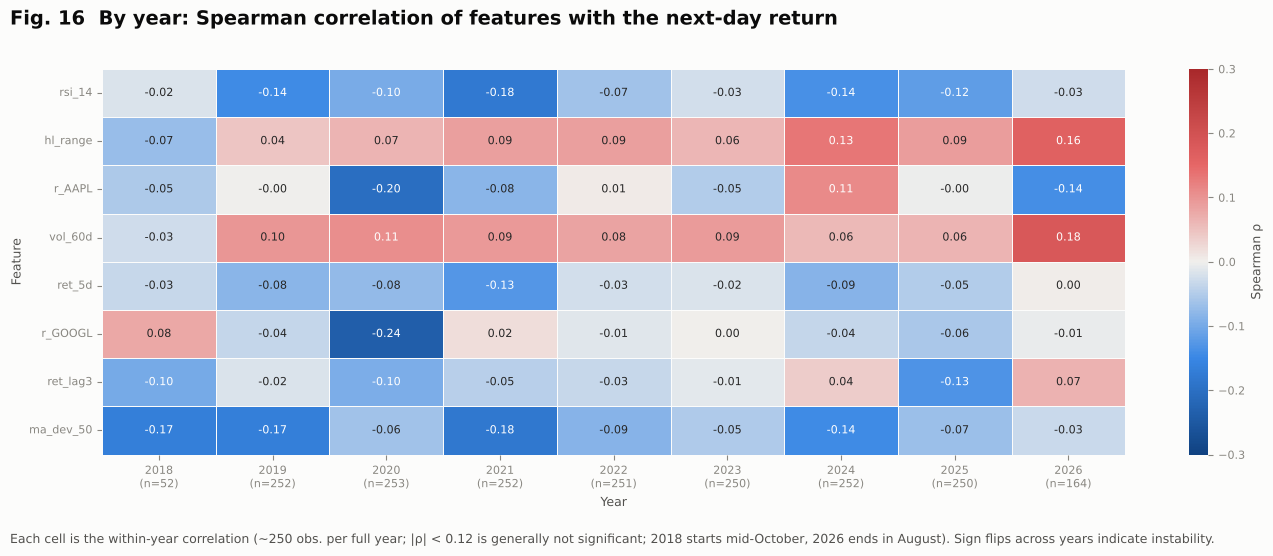

Saved: figures/16_yearly_corr_with_next_return.png


rsi_14       1.00
hl_range     0.89
r_AAPL       0.78
vol_60d      0.89
ret_5d       0.89
r_GOOGL      0.67
ret_lag3     0.78
ma_dev_50    1.00
Name: share of years with same sign as full sample, dtype: float64

In [27]:
top_rel = rel["spearman"].abs().sort_values(ascending=False).head(8).index.tolist()
yearly = data.groupby(data.index.year).apply(lambda g: g[top_rel].corrwith(g["next_ret"], method="spearman"))
n_year = data.groupby(data.index.year).size()
yearly.index = [f"{y}\n(n={n_year[y]})" for y in yearly.index]
fig, ax = plt.subplots(figsize=(14, 5.5))
sns.heatmap(yearly.T, cmap=DIVERGING, center=0, vmin=-0.3, vmax=0.3, annot=True, fmt=".2f", annot_kws={"fontsize": 8},
            linewidths=0.6, linecolor=C["surface"], ax=ax, cbar_kws={"label": "Spearman ρ"})
ax.grid(False)
ax.set_xlabel("Year"); ax.set_ylabel("Feature")
save(fig, "16_yearly_corr_with_next_return", "Fig. 16  By year: Spearman correlation of features with the next-day return",
     "Each cell is the within-year correlation (~250 obs. per full year; |ρ| < 0.12 is generally not significant; 2018 starts mid-October, 2026 ends in August). Sign flips across years indicate instability.")
sign_consistency = (np.sign(yearly) == np.sign(rel.loc[top_rel, "spearman"])).mean().rename("share of years with same sign as full sample")
sign_consistency.round(2)

**Observation:** Among the top-ranked features, `rsi_14` and `ma_dev_50` are negatively correlated with the next-day return in all 9 years (100% sign consistency), making them the most stable weak signals, though the yearly magnitude ranges only from -0.03 to -0.18 and is not significant in some years. `hl_range` and `vol_60d` are positive in 8 of 9 years, fairly stable. The negative correlations of `r_AAPL` and `r_GOOGL` come almost entirely from 2020 (-0.20, -0.24) and even flip positive for AAPL in 2024 — unstable relationships. The sign of `ret_lag3` alternates across years and is not reliable.

## 6. Summary

See [`eda_report.md`](eda_report.md) for the full write-up.

In [28]:
print("Figure files:")
for p in sorted(FIG_DIR.glob("*.png")):
    print(" -", p)

Figure files:
 - figures/01_feature_distributions.png
 - figures/02_returns_qq.png
 - figures/03_price_volume_timeseries.png
 - figures/04_adf_stationarity.png
 - figures/05_corr_heatmap_pearson.png
 - figures/06_corr_heatmap_spearman.png
 - figures/07_corr_dendrogram.png
 - figures/08_top_pairs_scatter.png
 - figures/09_rolling_correlation_60d.png
 - figures/10_corr_by_volatility_regime.png
 - figures/11_cross_correlation.png
 - figures/12_features_by_next_day_direction.png
 - figures/13_corr_with_next_return.png
 - figures/14_mutual_information.png
 - figures/15_returns_acf_pacf.png
 - figures/16_yearly_corr_with_next_return.png
